# 📊 Entendendo o Negócio da Y.Afisha

### 🏢 O Negócio da Y.Afisha

A **Y.Afisha** é uma empresa de **entretenimento/eventos** que opera um site onde:

- Pessoas visitam para descobrir eventos, shows, cinemas, restaurantes
- Fazem compras de ingressos ou reservas através do site  
- A empresa investe em marketing digital para atrair visitantes
- O objetivo é **converter visitantes em compradores** e maximizar o retorno do investimento em marketing

### 📋 As 3 Tabelas que usaremos e seu Significado no Negócio:


| Tabela | O que Representa | Colunas da Tabela | Significado no Negócio |
|--------|------------------|-------------------|------------------------|
| **🌐 visits** | Funil de entrada - todos que chegam ao site | • `uid`: Cada visitante<br>• `device`: Como acessam<br>• `start_ts/end_ts`: Tempo no site<br>• `source_id`: Canal de origem | Mede o **topo do funil** - quantas pessoas a empresa consegue atrair |
| **💰 orders** | Conversão - quem realmente compra | • `uid`: Quem comprou<br>• `buy_ts`: Quando comprou<br>• `revenue`: Quanto gastou | Mede o **fundo do funil** - quantos visitantes se tornam clientes pagantes |
| **📈 costs** | Investimento - quanto é gasto para atrair pessoas | • `source_id`: Canal de investimento<br>• `dt`: Quando gastaram<br>• `costs`: Quanto gastaram | Mede a **eficiência do investimento** - qual canal traz mais retorno |

### 🔄 Como as tabelas se conectam no negócio:

**COSTS** → **VISITS** → **ORDERS**

1. **Investem** em marketing (costs)
2. **Atraem** visitantes (visits)  
3. **Convertem** em vendas (orders)

**Objetivo da análise:** Descobrir qual canal de marketing traz mais clientes com melhor ROI!

# Bibliotecas usadas:

In [ ]:
import pandas as pd   
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D # Ferramenta que será usada para configurar a legenda do boxplot e histograma
import numpy as np

# 1. Carregando os dados e preparando-os para a análise

## 1.1 Otimizando os dados

### 1.1.1 Importando uma amostra dos dados para atimiza-los:

Para não sobrecarregar nosso trabalho com possiveis 'arquivos pesados', vamos inicialmente carregar uma amostra de 200 linhas dos nossos dados, para serem usadas para a otimização antes de importar os arquivos completos:

In [2]:
visits_test = pd.read_csv('../datasets/visits_log_us.csv', nrows = 200) # Acessos

orders_test = pd.read_csv('../datasets/orders_log_us.csv', nrows = 200) # Pedidos

costs_test = pd.read_csv('../datasets/costs_us.csv', nrows = 200) # Custos com Marketing

### 1.1.2. Imprimindo uma amostra de cada tabela:

In [3]:
visits_test.sample(5)

,Device,End Ts,Source Id,Start Ts,Uid
99,desktop,2018-01-30 09:28:00,2,2018-01-30 09:20:00,13153933924358373075
175,touch,2018-01-03 01:23:00,4,2018-01-03 01:17:00,17284573561484737376
114,touch,2017-11-13 21:49:00,9,2017-11-13 21:10:00,12415519988482411548
82,desktop,2017-12-13 10:56:00,3,2017-12-13 10:50:00,14259519155654778234
91,touch,2017-06-04 03:14:00,4,2017-06-04 03:11:00,13196018916609154741


In [4]:
orders_test.sample(5)

,Buy Ts,Revenue,Uid
36,2017-06-01 17:09:00,2.20,14528467823744531564
133,2017-06-02 12:32:00,3.89,18283164068049001576
138,2017-06-02 12:42:00,4.64,7423732129456637298
42,2017-06-01 17:27:00,110.00,11218073356336199381
35,2017-06-01 16:50:00,0.24,17654842465850522525


In [5]:
costs_test.sample(5)

,source_id,dt,costs
136,1,2017-10-15,49.88
193,1,2017-12-11,102.23
148,1,2017-10-27,62.53
199,1,2017-12-17,59.59
71,1,2017-08-11,29.93


### 1.1.3. Imprimindo as informações gerais de cada tabela, inclusive seu tamanho em memória usada: 

In [6]:
visits_test.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Device     200 non-null    object
 1   End Ts     200 non-null    object
 2   Source Id  200 non-null    int64 
 3   Start Ts   200 non-null    object
 4   Uid        200 non-null    uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 40.7 KB


In [7]:
orders_test.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   200 non-null    object 
 1   Revenue  200 non-null    float64
 2   Uid      200 non-null    uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 16.5 KB


In [8]:
costs_test.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  200 non-null    int64  
 1   dt         200 non-null    object 
 2   costs      200 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 14.8 KB


Notamos muitas colunas no formato 'object'. Será se não seria interessante trata-las para otimizar o uso de memória usada? Veremos isso a seguir

### 1.1.4. Tratando os titulos das colunas:

In [9]:
# Construindo uma função para tratar as colunas:
def trata_colunas(df):
    '''
        Essa função recebe um dataframe e retorna os titulos de suas colunas tratatos no formato SnakeCase, como uma lista.
        OBS: Não se aplica à caracteres especiais do latim.
    '''
    cols = df.columns
    cols_tratadas = []
    for col in cols:
        col = col.lower()
        col = col.replace(' ','_')
        cols_tratadas.append(col)
    cols = cols_tratadas
    return cols

In [10]:
# Aplicando a função para tratar as colunas dos nossos dataframes:
visits_test.columns = trata_colunas(visits_test)

orders_test.columns = trata_colunas(orders_test)

costs_test.columns = trata_colunas(costs_test)

### 1.1.5. Otimizando os dados:

In [11]:
# vamos analisar mais de perto a coluna 'device' de visits:
visits_test['device'].value_counts()

device
desktop    147
touch       53
Name: count, dtype: int64

Vemos que essa coluna trata-se de uma coluna categórica, contendo 2 categorias: desktop e touch.

 Assim, identificamos que as seguintes colunas devem ser convertidas para os respectivos tipos de dados abaixo, em prol de otimizar nossos arquivos de dados:

**visits:**
* 'device' --> 'category'
* 'end_ts' e 'start_ts' --> 'datetime'

**orders:**
* 'buy_ts' --> 'datetime'

**costs:**
* 'dt' --> 'datetime'

In [12]:
# Vamos converte-las:
# visits:
visits_test['device'] = visits_test['device'].astype('category')

visits_test['end_ts'] = pd.to_datetime(visits_test['end_ts'], format='%Y-%m-%d %H:%M:%S')

visits_test['start_ts'] = pd.to_datetime(visits_test['start_ts'], format='%Y-%m-%d %H:%M:%S')

# orders:
orders_test['buy_ts'] = pd.to_datetime(orders_test['buy_ts'], format='%Y-%m-%d %H:%M:%S')

# costs:
costs_test['dt'] = pd.to_datetime(costs_test['dt'], format='%Y-%m-%d')

### 1.1.6. Verificando o resultado da otimização:

In [13]:
visits_test.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   device     200 non-null    category      
 1   end_ts     200 non-null    datetime64[ns]
 2   source_id  200 non-null    int64         
 3   start_ts   200 non-null    datetime64[ns]
 4   uid        200 non-null    uint64        
dtypes: category(1), datetime64[ns](2), int64(1), uint64(1)
memory usage: 6.8 KB


In [14]:
orders_test.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   buy_ts   200 non-null    datetime64[ns]
 1   revenue  200 non-null    float64       
 2   uid      200 non-null    uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 4.8 KB


In [15]:
costs_test.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  200 non-null    int64         
 1   dt         200 non-null    datetime64[ns]
 2   costs      200 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 4.8 KB


Conseguimos diminuir em pelo menos 4 vezes a memória dos nossos dados. O que é muito bom. Agora podemos carregar os arquivos completos com base nesse tratamento.

## 1.2. Importando os dados completos já otimizados:

In [16]:
# Usando os parâmetros dtype e parse_dates para carregar nossos dados completos:
# parse_dates recebe uma lista para tratar dados no formato datetime
# dtype recebe um dicionário para tratar os outros tipos de dados

# é interessante colocar os nomes primitivos das colunas, já que o tratamento feito anteriormente foi apenas numa amostra de dados,
#  e assim, o python não vai reconhecer os tratados.

visits = pd.read_csv('../datasets/visits_log_us.csv', 
                     dtype={'Device':'category'}, 
                     parse_dates=['End Ts','Start Ts'])

orders = pd.read_csv('../datasets/orders_log_us.csv', 
                     parse_dates=['Buy Ts'])

costs = pd.read_csv('../datasets/costs_us.csv', 
                    parse_dates=['dt'])

In [17]:
# Tratando os títulos das colunas dos nossos dataframes completos:
visits.columns = trata_colunas(visits)

orders.columns = trata_colunas(orders)

costs.columns = trata_colunas(costs)

## 1.3. Imprimindo as informações gerais dos arquivos completos:

In [18]:
visits.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   device     359400 non-null  category      
 1   end_ts     359400 non-null  datetime64[ns]
 2   source_id  359400 non-null  int64         
 3   start_ts   359400 non-null  datetime64[ns]
 4   uid        359400 non-null  uint64        
dtypes: category(1), datetime64[ns](2), int64(1), uint64(1)
memory usage: 11.3 MB


In [19]:
orders.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   buy_ts   50415 non-null  datetime64[ns]
 1   revenue  50415 non-null  float64       
 2   uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB


In [20]:
costs.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   int64         
 1   dt         2542 non-null   datetime64[ns]
 2   costs      2542 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 59.7 KB


Uma ótima notícia: Não temos valores ausentes

# 2. Fazendo relatórios e calculando as métricas sobre:

## 2.1. O Produto;

### 2.1.1. Quantas pessoas usam o produto (em cada dia, semana e mês)?

#### 2.1.1.1. Visitas

In [21]:
# Vamos construir as colunas data, semana e mês para observar as métricas de usuário dau, wau e mau:

visits['data'] = visits['start_ts'].dt.to_period('D')  

visits['semana'] = visits['start_ts'].dt.to_period('W')  

visits['mes'] = visits['start_ts'].dt.to_period('M')  

visits.head()

,device,end_ts,source_id,start_ts,uid,data,semana,mes
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,2017-12-20,2017-12-18/2017-12-24,2017-12
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,2018-02-19,2018-02-19/2018-02-25,2018-02
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,2017-07-01,2017-06-26/2017-07-02,2017-07
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,2018-05-20,2018-05-14/2018-05-20,2018-05
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,2017-12-27,2017-12-25/2017-12-31,2017-12


In [22]:
# Vamos agregar os usuários unicos por data, semana e mes
dau = visits.groupby(['data','device'])['uid'].nunique().reset_index().rename(columns = {'uid':'visitas_diarias'}) # visitas diarias

wau = visits.groupby(['semana','device'])['uid'].nunique().reset_index().rename(columns = {'uid':'visitas_semanais'}) # visitas semanais 

mau = visits.groupby(['mes','device'])['uid'].nunique().reset_index().rename(columns = {'uid':'visitas_mensais'}) # visitas diarias

dau.head()


C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_23004\3897992893.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dau = visits.groupby(['data','device'])['uid'].nunique().reset_index().rename(columns = {'uid':'visitas_diarias'}) # visitas diarias
C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_23004\3897992893.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wau = visits.groupby(['semana','device'])['uid'].nunique().reset_index().rename(columns = {'uid':'visitas_semanais'}) # visitas semanais
C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_23004\3897992893.py:6: FutureWarning: The default of observed=False is de

,data,device,visitas_diarias
0,2017-06-01,desktop,455
1,2017-06-01,touch,153
2,2017-06-02,desktop,458
3,2017-06-02,touch,152
4,2017-06-03,desktop,307


In [23]:

# Calculando dau, wau e mau médias segmentadas por dispositivo:

# Para Desktop
dau_desktop = dau[dau['device'] == 'desktop']
wau_desktop = wau[wau['device'] == 'desktop']
mau_desktop = mau[mau['device'] == 'desktop']

avg_dau_desktop = dau_desktop['visitas_diarias'].mean()
avg_wau_desktop = wau_desktop['visitas_semanais'].mean()
avg_mau_desktop = mau_desktop['visitas_mensais'].mean()

# Para Touch
dau_touch = dau[dau['device'] == 'touch']
wau_touch = wau[wau['device'] == 'touch']
mau_touch = mau[mau['device'] == 'touch']

avg_dau_touch = dau_touch['visitas_diarias'].mean()
avg_wau_touch = wau_touch['visitas_semanais'].mean()
avg_mau_touch = mau_touch['visitas_mensais'].mean()

# Calculando as taxas de retenção por dispositivo
sticky_wau_desktop = round(100*(avg_dau_desktop/avg_wau_desktop), 2)
sticky_mau_desktop = round(100*(avg_dau_desktop/avg_mau_desktop), 2)

sticky_wau_touch = round(100*(avg_dau_touch/avg_wau_touch), 2)
sticky_mau_touch = round(100*(avg_dau_touch/avg_mau_touch), 2)

# Exibindo os resultados
print("=== TAXAS DE RETENÇÃO POR DISPOSITIVO ===")
print(f"\n📱 DESKTOP:")
print(f"   • Sticky WAU: {sticky_wau_desktop}%")
print(f"   • Sticky MAU: {sticky_mau_desktop}%")

print(f"\n📱 TOUCH:")
print(f"   • Sticky WAU: {sticky_wau_touch}%")
print(f"   • Sticky MAU: {sticky_mau_touch}%")

print(f"\n📊 COMPARAÇÃO:")
print(f"   • Desktop vs Touch (WAU): {sticky_wau_desktop}% vs {sticky_wau_touch}%")
print(f"   • Desktop vs Touch (MAU): {sticky_mau_desktop}% vs {sticky_mau_touch}%")

=== TAXAS DE RETENÇÃO POR DISPOSITIVO ===

📱 DESKTOP:
   • Sticky WAU: 15.96%
   • Sticky MAU: 3.94%

📱 TOUCH:
   • Sticky WAU: 15.42%
   • Sticky MAU: 3.69%

📊 COMPARAÇÃO:
   • Desktop vs Touch (WAU): 15.96% vs 15.42%
   • Desktop vs Touch (MAU): 3.94% vs 3.69%


conclusões:

Podemos observar que:
- Em média, apenas ~16% dos usuários semanais visitam o site diariamente. A maioria dos usuários (84%) não tem o hábito de usar o produto todos os dias.
- Apenas cerca de 4% dos usuários mensais são usuários diários ativos. Isso confirma que o produto não é usado diariamente pela maioria.
- O comportamento dos visitantes não mudam muito de dispositivo para dispositivo, mas o desktop mostra-se ligeiramente a frente


In [24]:
# Plotando gráficos de linhas para entender o comportamento de dau, wau e mau ao longo ndo tempo:
# Agregando os usuários únicos por data, semana, mês E dispositivo
dau_device = visits.groupby(['data', 'device'])['uid'].nunique().reset_index().rename(columns={'uid':'visitas_diarias'})
wau_device = visits.groupby(['semana', 'device'])['uid'].nunique().reset_index().rename(columns={'uid':'visitas_semanais'})
mau_device = visits.groupby(['mes', 'device'])['uid'].nunique().reset_index().rename(columns={'uid':'visitas_mensais'})

# Plotando gráficos de linhas segmentados por dispositivo:

# DAU por dispositivo
fig_dau_device = px.line(dau_device, 
                        x='data', 
                        y='visitas_diarias',
                        color='device',
                        title='Uso Diário ao longo do tempo por Dispositivo (DAU)', 
                        labels={'data': 'Data da Visita', 'visitas_diarias': 'Número de Visitantes Únicos', 'device': 'Dispositivo'},
                        color_discrete_map={'desktop': 'black', 'touch': 'orange'})

dau_device_plot = dau_device.copy()
dau_device_plot['data'] = dau_device_plot['data'].dt.to_timestamp()

wau_device_plot = wau_device.copy()
wau_device_plot['semana'] = wau_device_plot['semana'].dt.to_timestamp()

mau_device_plot = mau_device.copy()
mau_device_plot['mes'] = mau_device_plot['mes'].dt.to_timestamp()

# DAU por dispositivo
fig_dau_device = px.line(
    dau_device_plot,
    x='data',
    y='visitas_diarias',
    color='device',
    title='Uso Diário ao longo do tempo por Dispositivo (DAU)',
    labels={'data': 'Data da Visita', 'visitas_diarias': 'Número de Visitantes Únicos', 'device': 'Dispositivo'},
    color_discrete_map={'desktop': 'black', 'touch': 'orange'}
)
fig_dau_device.show()

# WAU por dispositivo
fig_wau_device = px.line(
    wau_device_plot,
    x='semana',
    y='visitas_semanais',
    color='device',
    title='Uso Semanal ao longo do tempo por Dispositivo (WAU)',
    labels={'semana': 'Data Inicial da Semana de Visita', 'visitas_semanais': 'Número de Visitantes Únicos', 'device': 'Dispositivo'},
    color_discrete_map={'desktop': 'blue', 'touch': 'red'}
)
fig_wau_device.show()

# MAU por dispositivo
fig_mau_device = px.line(
    mau_device_plot,
    x='mes',
    y='visitas_mensais',
    color='device',
    title='Uso Mensal ao longo do tempo por Dispositivo (MAU)',
    labels={'mes': 'Mês', 'visitas_mensais': 'Número de Visitantes Únicos', 'device': 'Dispositivo'},
    color_discrete_map={'desktop': 'green', 'touch': 'purple'}
)
fig_mau_device.show()

C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_23004\1930499208.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dau_device = visits.groupby(['data', 'device'])['uid'].nunique().reset_index().rename(columns={'uid':'visitas_diarias'})
C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_23004\1930499208.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wau_device = visits.groupby(['semana', 'device'])['uid'].nunique().reset_index().rename(columns={'uid':'visitas_semanais'})
C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_23004\1930499208.py:5: FutureWarning: The default of observed=False is deprecated and will be chan

In [25]:
# Calculando o Sticky WAU e Sticky MAU por dispositivo
sticky_wau_desktop = round((avg_dau_desktop / avg_wau_desktop) * 100, 2)
sticky_mau_desktop = round((avg_dau_desktop / avg_mau_desktop) * 100, 2)

sticky_wau_touch = round((avg_dau_touch / avg_wau_touch) * 100, 2)
sticky_mau_touch = round((avg_dau_touch / avg_mau_touch) * 100, 2)

print(f"Desktop — Sticky WAU: {sticky_wau_desktop}% | Sticky MAU: {sticky_mau_desktop}%")
print(f"Touch — Sticky WAU: {sticky_wau_touch}% | Sticky MAU: {sticky_mau_touch}%")

Desktop — Sticky WAU: 15.96% | Sticky MAU: 3.94%
Touch — Sticky WAU: 15.42% | Sticky MAU: 3.69%


Conclusões: 

Percebemos que quanto menor o tempo gráfico, mais ruidos temos no gráfico, consequentemente, menos certezas. O contrário acontece quando aumentamos o tempo de análise. Porém, prazos menores são uma boa opção para analisar sazionalidades semanais

Os dados revelam que desktop e touch apresentam padrões muito similares de uso:

- Sticky WAU: Desktop (15,94%) vs Touch (15,40%) - diferença mínima
- Sticky MAU: Desktop (3,94%) vs Touch (3,69%) - comportamento quase idêntico
Insights dos Gráficos Temporais

📈 Tendências Paralelas:
- Ambos os dispositivos seguem as mesmas tendências sazonais
- Desktop sempre superior em volume absoluto de usuários
- Padrões semanais consistentes em ambos os dispositivos

🔍 Pontos de Atenção:
- Pico conjunto: 24/11/2017 (Black Friday) - ambos dispositivos
- Vale extremo: 31/03/2018 - possível problema técnico
- Crescimento até nov/2017, depois estabilização/declínio

#### 2.1.1.2. Retenção

In [26]:
# Agora, vamos calcular as taxas de retenção semanais e mensais móveis (ao longo do tempo):
# para isso, vamos precisar extrair as semanas e meses das datas do dataframe dau, calcular o dau medio semanal e mensal para cada semana e mes,
#e depois junta-lo com wau e mau atravéz dessas colunas para obter as informações dos indices de retenção semanal e mensal:

# Converte o Period para Timestamp antes de aplicar o to_datetime ou as extrações
dau['data'] = dau['data'].dt.to_timestamp()

dau['mes'] = dau['data'].dt.to_period('M')
dau['semana'] = dau['data'].dt.to_period('W')

# Calculando o dau médio semanal e mensal:
dau_mensal = dau.groupby('mes')['visitas_diarias'].mean().round(0).reset_index().rename(columns = {'visitas_diarias':'dau_mensal'})
dau_semanal = dau.groupby('semana')['visitas_diarias'].mean().round(0).reset_index().rename(columns = {'visitas_diarias':'dau_semanal'})

# juntando as informações com wau e mau:
wau = wau.merge(dau_semanal, on = 'semana')
mau = mau.merge(dau_mensal, on = 'mes')

# Criando as colunas de retenção móvel:
wau['sticky_wau'] = 100 * (wau['dau_semanal']/wau['visitas_semanais'])
mau['sticky_mau'] = 100 * (mau['dau_mensal']/mau['visitas_mensais'])

wau.head()

,semana,device,visitas_semanais,dau_semanal,sticky_wau
0,2017-05-29/2017-06-04,desktop,1451,268.0,18.470021
1,2017-05-29/2017-06-04,touch,584,268.0,45.890411
2,2017-06-05/2017-06-11,desktop,3061,325.0,10.617445
3,2017-06-05/2017-06-11,touch,1113,325.0,29.200359
4,2017-06-12/2017-06-18,desktop,2129,215.0,10.098638


In [27]:
# Plotando um gráfico de linha para visualizar a retenção móvel ao longo do tempo:


# Primeiro, precisamos recalcular as métricas de retenção segmentadas por dispositivo
# Calculando DAU médio semanal e mensal por dispositivo
dau_device['data'] = dau_device['data'].dt.to_timestamp()
dau_device['mes'] = dau_device['data'].dt.to_period('M')
dau_device['semana'] = dau_device['data'].dt.to_period('W')

# DAU médio semanal por dispositivo
dau_semanal_device = dau_device.groupby(['semana', 'device'])['visitas_diarias'].mean().round(0).reset_index().rename(columns={'visitas_diarias':'dau_semanal'})

# DAU médio mensal por dispositivo  
dau_mensal_device = dau_device.groupby(['mes', 'device'])['visitas_diarias'].mean().round(0).reset_index().rename(columns={'visitas_diarias':'dau_mensal'})

# Juntando com WAU e MAU por dispositivo
wau_device = wau_device.merge(dau_semanal_device, on=['semana', 'device'])
mau_device = mau_device.merge(dau_mensal_device, on=['mes', 'device'])

# Criando as colunas de retenção móvel por dispositivo
wau_device['sticky_wau'] = 100 * (wau_device['dau_semanal']/wau_device['visitas_semanais'])
mau_device['sticky_mau'] = 100 * (mau_device['dau_mensal']/mau_device['visitas_mensais'])

# Filtrando a última semana (que tem retenção extrema por definição)
ultima_semana = wau_device['semana'].max()
wau_device_filtered = wau_device[wau_device['semana'] != ultima_semana]

# Plotando gráficos de retenção segmentados por dispositivo
# Sticky WAU por dispositivo
fig_sticky_wau_device = px.line(wau_device_filtered, 
                               x='semana', 
                               y='sticky_wau',
                               color='device',
                               title='Taxa de Retenção Semanal por Dispositivo (Sticky WAU)',
                               markers=True,
                               labels={'semana': 'Data de Início da Semana', 'sticky_wau': 'Sticky WAU (%)', 'device': 'Dispositivo'},
                               color_discrete_map={'desktop': 'blue', 'touch': 'orange'})

wau_device_filtered = wau_device_filtered.assign(
    semana=lambda df: df['semana'].dt.to_timestamp()
)

mau_device = mau_device.assign(
    mes=lambda df: df['mes'].dt.to_timestamp()
)

fig_sticky_wau_device = px.line(
    wau_device_filtered,
    x='semana',
    y='sticky_wau',
    color='device',
    title='Taxa de Retenção Semanal por Dispositivo (Sticky WAU)',
    markers=True,
    labels={
        'semana': 'Data de Início da Semana',
        'sticky_wau': 'Sticky WAU (%)',
        'device': 'Dispositivo'
    },
    color_discrete_map={'desktop': 'blue', 'touch': 'orange'}
)

fig_sticky_wau_device.show()

# Sticky MAU por dispositivo
fig_sticky_mau_device = px.line(mau_device, 
                               x='mes', 
                               y='sticky_mau',
                               color='device',
                               title='Taxa de Retenção Mensal por Dispositivo (Sticky MAU)',
                               markers=True,
                               labels={'mes': 'Mês', 'sticky_mau': 'Sticky MAU (%)', 'device': 'Dispositivo'},
                               color_discrete_map={'desktop': 'green', 'touch': 'red'})

fig_sticky_mau_device.show()

C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_23004\560488963.py:11: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_23004\560488963.py:14: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



Conclusões:

Gráficos de Retenção (Sticky WAU/MAU):

- Padrões similares: Desktop e touch apresentam trajetórias quase idênticas de retenção ao longo do tempo
- Desktop ligeiramente superior: Mantém consistentemente taxas de retenção ~0,5% maiores que touch

### 2.1.2. Quantas sessões ocorrem por dia? (um usuário pode realizar várias sessões).

In [28]:
# devemos contar a quantidade de sessoes iniciadas por dia:
# Segmentando sessões por dia E por dispositivo:
sessoes_por_dia_device = visits.groupby(['data', 'device'])['start_ts'].count().reset_index().rename(columns={'start_ts':'sessoes'})

# Estatísticas descritivas por dispositivo
print("=== ESTATÍSTICAS DE SESSÕES POR DISPOSITIVO ===")
print("\n DESKTOP:")
sessoes_desktop = sessoes_por_dia_device[sessoes_por_dia_device['device'] == 'desktop']['sessoes']
print(sessoes_desktop.describe())

print("\n TOUCH:")
sessoes_touch = sessoes_por_dia_device[sessoes_por_dia_device['device'] == 'touch']['sessoes']
print(sessoes_touch.describe())

=== ESTATÍSTICAS DE SESSÕES POR DISPOSITIVO ===

 DESKTOP:
count     364.000000
mean      721.337912
std       322.327697
min         1.000000
25%       457.250000
50%       711.000000
75%       961.500000
max      3152.000000
Name: sessoes, dtype: float64

 TOUCH:
count    364.000000
mean     266.024725
std      111.589231
min        0.000000
25%      179.500000
50%      278.000000
75%      336.500000
max      890.000000
Name: sessoes, dtype: float64


C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_23004\1234685920.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



conclusão:

- Proporção consistente: Desktop mantém aproximadamente 3:1 em relação ao touch, similar ao padrão observado nos investimentos de marketing (74,3% vs 25,7%)
- Comportamento sazonal similar: Ambos os dispositivos seguem os mesmos padrões temporais, com picos e vales coincidentes
- Estabilidade relativa: Touch apresenta menor variabilidade (desvio padrão menor), enquanto desktop tem maior amplitude de variação
- Normalidade mantida: Quando combinados, continuamos com a média de ~987 sessões por dia, confirmando que não há usuários fazendo sessões em excesso

In [29]:
# DAU
# Gráfico de sessões (segmentado por dispositivo)
fig_sessoes_device = px.line(sessoes_por_dia_device, 
                            x='data', 
                            y='sessoes',
                            color='device',
                            title='Sessões diárias ao longo do tempo por Dispositivo', 
                            labels={'data': 'Dia', 'sessoes': 'Número de Sessões', 'device': 'Dispositivo'},
                            color_discrete_map={'desktop': 'blue', 'touch': 'orange'})

sessoes_por_dia_device_plot = sessoes_por_dia_device.copy()
sessoes_por_dia_device_plot['data'] = sessoes_por_dia_device_plot['data'].dt.to_timestamp()

fig_sessoes_device = px.line(
    sessoes_por_dia_device_plot,
    x='data',
    y='sessoes',
    color='device',
    title='Sessões diárias ao longo do tempo por Dispositivo',
    labels={'data': 'Dia', 'sessoes': 'Número de Sessões', 'device': 'Dispositivo'},
    color_discrete_map={'desktop': 'blue', 'touch': 'orange'}
)
fig_sessoes_device.show()

conclusões:

📈 Pico Extremo:
- 24/11/2017: Desktop atingiu 3.152 sessões (Black Friday) - maior pico do período
- Touch acompanhou proporcionalmente com 890 sessões

📉 Vale Preocupante:
- 31/03/2018: Apenas 1 sessão total registrada - possível falha técnica que afetou ambas as plataformas simultaneamente

📊 Características Estatísticas:
- Touch mais estável: Menor variabilidade (desvio padrão menor)
- Desktop mais volátil: Maior amplitude de variação, mas também maior volume absoluto
- Proporção constante: A relação 3:1 se mantém estável ao longo de todo o período

### 2.1.3. Que comprimento tem cada sessão?

In [30]:
# Segmentando duração por dispositivo:
visits['duration'] = visits['end_ts'] - visits['start_ts']

# Convertendo para minutos e filtrando durações válidas
visits['duration'] = visits['duration'].dt.total_seconds() / 60
visits_ideal = visits[visits['duration'] >= 0]

# Estatísticas descritivas por dispositivo
print("=== ESTATÍSTICAS DE DURAÇÃO POR DISPOSITIVO ===")
print("\n📱 DESKTOP:")
duration_desktop = visits_ideal[visits_ideal['device'] == 'desktop']['duration']
print(duration_desktop.describe())

print("\n📱 TOUCH:")
duration_touch = visits_ideal[visits_ideal['device'] == 'touch']['duration']
print(duration_touch.describe())

# Calculando moda por dispositivo
moda_desktop = duration_desktop.mode()[0]
moda_touch = duration_touch.mode()[0]

print(f"\n📊 COMPARAÇÃO DE MODAS:")
print(f"   • Desktop: {int(moda_desktop)} minuto(s)")
print(f"   • Touch: {int(moda_touch)} minuto(s)")

=== ESTATÍSTICAS DE DURAÇÃO POR DISPOSITIVO ===

📱 DESKTOP:
count    262565.000000
mean         11.721867
std          17.783834
min           0.000000
25%           2.000000
50%           6.000000
75%          15.000000
max         711.000000
Name: duration, dtype: float64

📱 TOUCH:
count    96833.000000
mean         7.993657
std         12.542192
min          0.000000
25%          1.000000
50%          3.000000
75%         10.000000
max        514.000000
Name: duration, dtype: float64

📊 COMPARAÇÃO DE MODAS:
   • Desktop: 1 minuto(s)
   • Touch: 1 minuto(s)


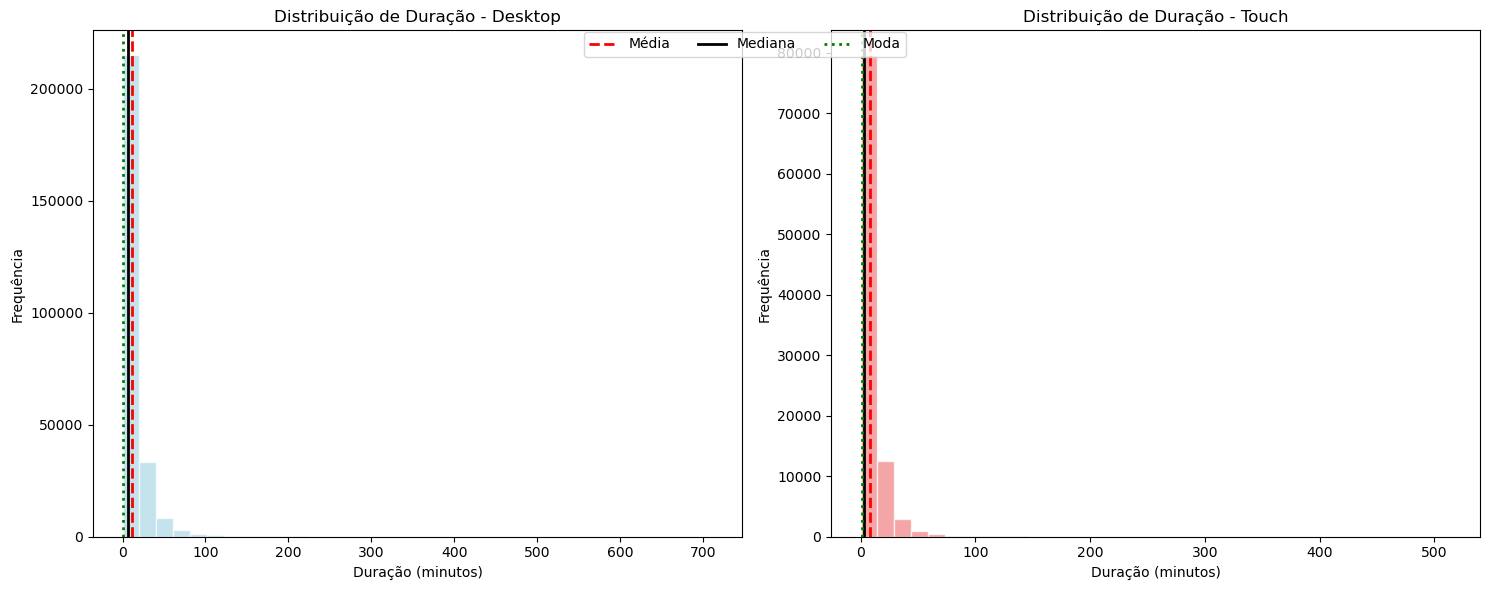

=== COMPARAÇÃO DE DURAÇÃO POR DISPOSITIVO ===

📱 DESKTOP:
   • Média: 11.72 minutos
   • Mediana: 6.00 minutos
   • Moda: 1 minuto(s)

📱 TOUCH:
   • Média: 7.99 minutos
   • Mediana: 3.00 minutos
   • Moda: 1 minuto(s)

📊 DIFERENÇAS:
   • Diferença na Média: 3.73 minutos
   • Diferença na Mediana: 3.00 minutos
   • Razão Desktop/Touch (Média): 1.47x


In [31]:
# Criando histogramas separados por dispositivo
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histograma para Desktop
duration_desktop = visits_ideal[visits_ideal['device'] == 'desktop']['duration']
mean_desktop = duration_desktop.mean()
median_desktop = duration_desktop.median()
mode_desktop = duration_desktop.mode()[0]

axes[0].hist(duration_desktop, bins=35, color='lightblue', edgecolor='white', alpha=0.7)
axes[0].axvline(mean_desktop, color='red', linestyle='--', linewidth=2)
axes[0].axvline(median_desktop, color='black', linestyle='-', linewidth=2)
axes[0].axvline(mode_desktop, color='green', linestyle=':', linewidth=2)
axes[0].set_title('Distribuição de Duração - Desktop')
axes[0].set_xlabel('Duração (minutos)')
axes[0].set_ylabel('Frequência')

# Histograma para Touch
duration_touch = visits_ideal[visits_ideal['device'] == 'touch']['duration']
mean_touch = duration_touch.mean()
median_touch = duration_touch.median()
mode_touch = duration_touch.mode()[0]

axes[1].hist(duration_touch, bins=35, color='lightcoral', edgecolor='white', alpha=0.7)
axes[1].axvline(mean_touch, color='red', linestyle='--', linewidth=2)
axes[1].axvline(median_touch, color='black', linestyle='-', linewidth=2)
axes[1].axvline(mode_touch, color='green', linestyle=':', linewidth=2)
axes[1].set_title('Distribuição de Duração - Touch')
axes[1].set_xlabel('Duração (minutos)')
axes[1].set_ylabel('Frequência')

# Criando legenda comum
legend_elements = [
    Line2D([0], [0], color='red', lw=2, ls='--', label='Média'),
    Line2D([0], [0], color='black', lw=2, ls='-', label='Mediana'),
    Line2D([0], [0], color='green', lw=2, ls=':', label='Moda')
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=3)

plt.tight_layout()
plt.show()

# Comparando as estatísticas
print("=== COMPARAÇÃO DE DURAÇÃO POR DISPOSITIVO ===")
print(f"\n📱 DESKTOP:")
print(f"   • Média: {mean_desktop:.2f} minutos")
print(f"   • Mediana: {median_desktop:.2f} minutos") 
print(f"   • Moda: {int(mode_desktop)} minuto(s)")

print(f"\n📱 TOUCH:")
print(f"   • Média: {mean_touch:.2f} minutos")
print(f"   • Mediana: {median_touch:.2f} minutos")
print(f"   • Moda: {int(mode_touch)} minuto(s)")

print(f"\n📊 DIFERENÇAS:")
print(f"   • Diferença na Média: {abs(mean_desktop - mean_touch):.2f} minutos")
print(f"   • Diferença na Mediana: {abs(median_desktop - median_touch):.2f} minutos")
print(f"   • Razão Desktop/Touch (Média): {mean_desktop/mean_touch:.2f}x")

conclusão:

- As diferenças entre a moda, a mediana e a média são gritantes. Dessa forma, a moda representa melhor nosso conjunto de dados sobre duração de cada sessão. Assim, podemos dizer que cada sessão dura aproximadamente 1 minuto (em ambos os dispositivos)
- A mediana mostra uma sessão maior em desktops (é o dobro de dispositivos touch)

### 2.1.4. Com que frequência os usuários voltam?

In [32]:
# Criando a coluna do primeiro acesso:
primeiro_acesso = visits.groupby('uid')['start_ts'].min().reset_index().rename(columns = {'start_ts':'primeiro_acesso'})

visits = visits.merge(
    primeiro_acesso,
    on = 'uid'
)

In [33]:
# Criando uma coluna para a diferença entre a data de acesso atual e a data de primeiro acesso, para cada acesso
visits['diferenca'] = visits['start_ts'] - visits['primeiro_acesso']

# ordenando para ter linhas de mesmo usuario ordenada por data de acesso
visits_sort = visits.sort_values(by = ['uid','start_ts']).reset_index(drop = True) 

# Criando a coluna 'visto_por_ultimo' para marcar a diferença entre um acesso e acesso anterior, para cada usuário. A partir da diferença de uma linha 
# e sua anterior na coluna diferenca
visits_sort['visto_por_ultimo'] = visits_sort['diferenca'].diff()
visits_sort.head(8)

,device,end_ts,source_id,start_ts,uid,data,semana,mes,duration,primeiro_acesso,diferenca,visto_por_ultimo
0,touch,2018-03-01 17:33:00,3,2018-03-01 17:27:00,11863502262781,2018-03-01,2018-02-26/2018-03-04,2018-03,6.0,2018-03-01 17:27:00,0 days 00:00:00,NaT
1,touch,2018-02-06 15:57:00,2,2018-02-06 15:55:00,49537067089222,2018-02-06,2018-02-05/2018-02-11,2018-02,2.0,2018-02-06 15:55:00,0 days 00:00:00,0 days 00:00:00
2,desktop,2017-06-07 18:48:00,3,2017-06-07 18:47:00,297729379853735,2017-06-07,2017-06-05/2017-06-11,2017-06,1.0,2017-06-07 18:47:00,0 days 00:00:00,0 days 00:00:00
3,desktop,2017-09-18 23:07:00,2,2017-09-18 22:49:00,313578113262317,2017-09-18,2017-09-18/2017-09-24,2017-09,18.0,2017-09-18 22:49:00,0 days 00:00:00,0 days 00:00:00
4,desktop,2018-02-18 15:26:00,2,2018-02-18 15:17:00,313578113262317,2018-02-18,2018-02-12/2018-02-18,2018-02,9.0,2017-09-18 22:49:00,152 days 16:28:00,152 days 16:28:00
5,desktop,2018-03-11 17:29:00,2,2018-03-11 17:23:00,313578113262317,2018-03-11,2018-03-05/2018-03-11,2018-03,6.0,2017-09-18 22:49:00,173 days 18:34:00,21 days 02:06:00
6,desktop,2017-09-30 14:38:00,5,2017-09-30 14:29:00,325320750514679,2017-09-30,2017-09-25/2017-10-01,2017-09,9.0,2017-09-30 14:29:00,0 days 00:00:00,-174 days +05:26:00
7,desktop,2018-02-26 12:34:00,5,2018-02-26 12:33:00,325320750514679,2018-02-26,2018-02-26/2018-03-04,2018-02,1.0,2017-09-30 14:29:00,148 days 22:04:00,148 days 22:04:00


Veja que um 'visto_por_ultimo' negativo ou nulo significa o primeiro acesso do usuário, o que não nos interessa para a frequência com que os usuários voltam a acessar os serviços. Vamos descartar esses valores e armazenar as linhas na tabela visits_frequencia.

In [34]:

# Converter para horas
visits_sort['visto_por_ultimo'] = (visits_sort['visto_por_ultimo'].dt.total_seconds() / 3600).round(0)


# Filtrando para valores positivos:
visits_frequencia = visits_sort[visits_sort['visto_por_ultimo'] > 0].reset_index(drop = True)

visits_frequencia.head()

,device,end_ts,source_id,start_ts,uid,data,semana,mes,duration,primeiro_acesso,diferenca,visto_por_ultimo
0,desktop,2018-02-18 15:26:00,2,2018-02-18 15:17:00,313578113262317,2018-02-18,2018-02-12/2018-02-18,2018-02,9.0,2017-09-18 22:49:00,152 days 16:28:00,3664.0
1,desktop,2018-03-11 17:29:00,2,2018-03-11 17:23:00,313578113262317,2018-03-11,2018-03-05/2018-03-11,2018-03,6.0,2017-09-18 22:49:00,173 days 18:34:00,506.0
2,desktop,2018-02-26 12:34:00,5,2018-02-26 12:33:00,325320750514679,2018-02-26,2018-02-26/2018-03-04,2018-02,1.0,2017-09-30 14:29:00,148 days 22:04:00,3574.0
3,desktop,2017-10-21 21:44:00,2,2017-10-21 20:52:00,526778907996220,2017-10-21,2017-10-16/2017-10-22,2017-10,52.0,2017-10-21 17:51:00,0 days 03:01:00,3.0
4,desktop,2018-01-08 11:37:00,2,2018-01-08 11:34:00,526778907996220,2018-01-08,2018-01-08/2018-01-14,2018-01,3.0,2017-10-21 17:51:00,78 days 17:43:00,1887.0


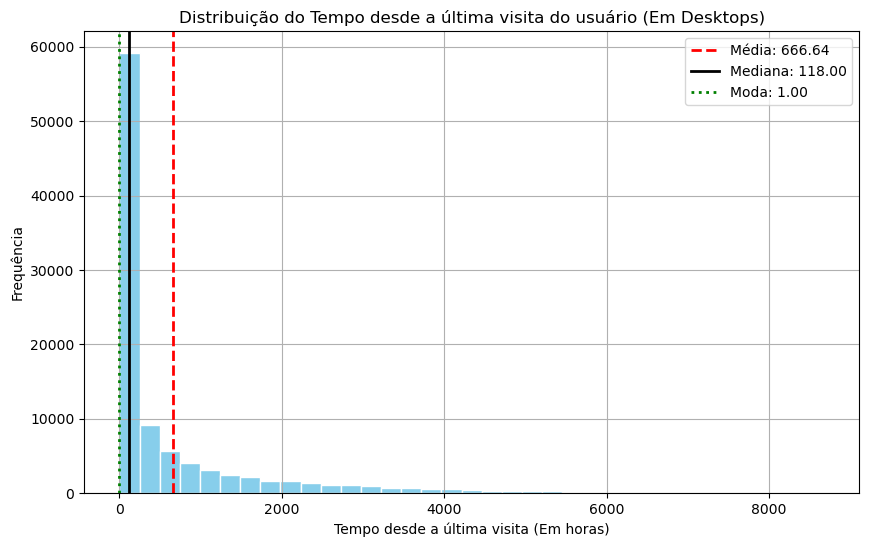

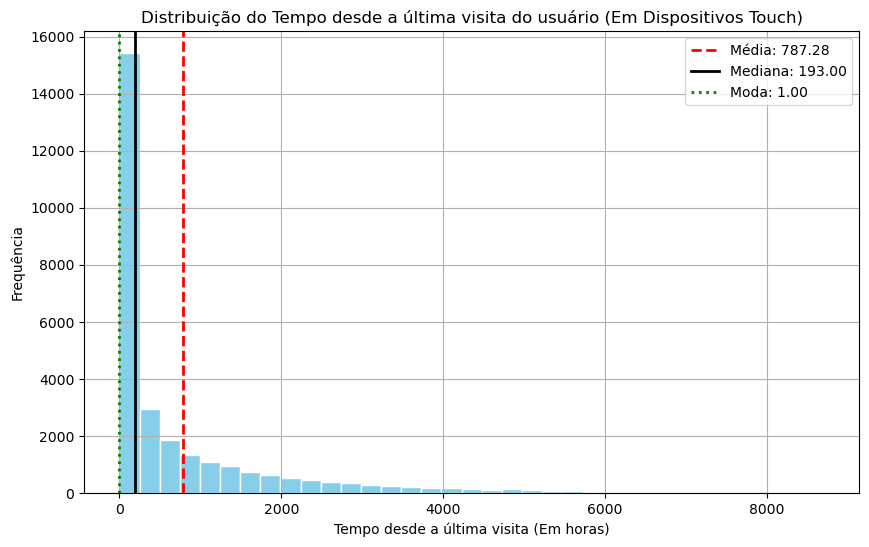

In [35]:
# Observando a distribuição dos valores da coluna 'visto_por_ultimo', por dispositivo
desktop = visits_frequencia[visits_frequencia['device'] == 'desktop']
touch = visits_frequencia[visits_frequencia['device'] == 'touch']

# desktop
mean_val = desktop['visto_por_ultimo'].mean()
median_val = desktop['visto_por_ultimo'].median()
mode_val = desktop['visto_por_ultimo'].mode()[0] # Pegamos o primeiro valor da moda

plt.figure(figsize=(10, 6))
desktop['visto_por_ultimo'].hist(bins=35, color='skyblue', edgecolor='white')

plt.axvline(mean_val, color='red', linestyle='--', linewidth=2)
plt.axvline(median_val, color='black', linestyle='-', linewidth=2)
plt.axvline(mode_val, color='green', linestyle=':', linewidth=2)

legend_elements = [
    Line2D([0], [0], color='red', lw=2, ls='--', label=f'Média: {mean_val:.2f}'),
    Line2D([0], [0], color='black', lw=2, ls='-', label=f'Mediana: {median_val:.2f}'),
    Line2D([0], [0], color='green', lw=2, ls=':', label=f'Moda: {mode_val:.2f}')
]

plt.legend(handles=legend_elements)

plt.title('Distribuição do Tempo desde a última visita do usuário (Em Desktops)')
plt.xlabel('Tempo desde a última visita (Em horas)')
plt.ylabel('Frequência')

plt.show()

# touch
mean_val = touch['visto_por_ultimo'].mean()
median_val = touch['visto_por_ultimo'].median()
mode_val = touch['visto_por_ultimo'].mode()[0] # Pegamos o primeiro valor da moda

plt.figure(figsize=(10, 6))
touch['visto_por_ultimo'].hist(bins=35, color='skyblue', edgecolor='white')

plt.axvline(mean_val, color='red', linestyle='--', linewidth=2)
plt.axvline(median_val, color='black', linestyle='-', linewidth=2)
plt.axvline(mode_val, color='green', linestyle=':', linewidth=2)

legend_elements = [
    Line2D([0], [0], color='red', lw=2, ls='--', label=f'Média: {mean_val:.2f}'),
    Line2D([0], [0], color='black', lw=2, ls='-', label=f'Mediana: {median_val:.2f}'),
    Line2D([0], [0], color='green', lw=2, ls=':', label=f'Moda: {mode_val:.2f}')
]

plt.legend(handles=legend_elements)

plt.title('Distribuição do Tempo desde a última visita do usuário (Em Dispositivos Touch)')
plt.xlabel('Tempo desde a última visita (Em horas)')
plt.ylabel('Frequência')

plt.show()


Analisando o nosso histograma, temos bons motivos para escolher a moda para responder a nossa pergunta principal desse item, já que a assimetria entre moda, mediana e média é gigantesca. Os motivos é que a moda:

- Representa o comportamento mais comum: A moda nos diz qual é o intervalo de tempo mais frequente entre visitas
- É menos sensível a outliers: Usuários que ficam meses sem voltar não distorcem o resultado
- É mais relevante para o negócio: Saber qual é o padrão mais comum de retorno ajuda no planejamento de campanhas

In [36]:
print(f'A moda é: {int(mode_val)} hora')

A moda é: 1 hora


In [37]:
# vamos analisar as visitas de usuários vistos por último ha 1 hora:
visits_modal = visits_frequencia[visits_frequencia['visto_por_ultimo'] == 1]

acessos_moda = visits_modal.shape[0]

print(f'Tivemos {acessos_moda} de acessos com um intervalo de 1 hora desde o último acesso. Vamos investigar isso mais de perto.')

Tivemos 7962 de acessos com um intervalo de 1 hora desde o último acesso. Vamos investigar isso mais de perto.


In [38]:
# Fazendo uma analise de coorte da retenção:
visits['lifetime'] = visits['diferenca'].dt.days

visits['lifetime'] = (visits['lifetime'] / 30).astype('int64') # Convertendo lifetime para mes

# Convertendo primeiro acesso para mes:
visits['primeiro_acesso'] = visits['primeiro_acesso'].dt.to_period('M')

visits.head()

,device,end_ts,source_id,start_ts,uid,data,semana,mes,duration,primeiro_acesso,diferenca,lifetime
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,2017-12-20,2017-12-18/2017-12-24,2017-12,18.0,2017-12,0 days 00:00:00,0
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,2018-02-19,2018-02-19/2018-02-25,2018-02,28.0,2018-02,0 days 00:00:00,0
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,2017-07-01,2017-06-26/2017-07-02,2017-07,0.0,2017-07,0 days 00:00:00,0
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,2018-05-20,2018-05-14/2018-05-20,2018-05,24.0,2018-03,71 days 14:54:00,2
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,2017-12-27,2017-12-25/2017-12-31,2017-12,0.0,2017-12,0 days 00:00:00,0


In [39]:
# Agrupando a quanntidade de visitas por usuários de visits_modal, e ordenando para saber se há anormalidade

max_login_modal = visits_modal.groupby('uid')['start_ts'].count().reset_index().sort_values(by = 'start_ts', ascending = False).reset_index(drop = True)

max_login_modal.head()

,uid,start_ts
0,12869801667763685675,250
1,3263486045884611639,105
2,11255648391090536411,74
3,17030528792926543083,71
4,10403169074343195591,52


In [40]:

# Calcula a coorte de usuários por mês de primeira visita e tempo de vida
cohort = visits.groupby(['primeiro_acesso', 'lifetime']).agg({'uid': 'nunique'}).reset_index()

# Seleciona a coorte inicial (lifetime == 0) e renomeia a coluna
inicial = cohort[cohort['lifetime'] == 0][['primeiro_acesso', 'uid']]
inicial = inicial.rename(columns={'uid': 'users'})

# Junta a coorte inicial com a coorte completa e calcula a taxa de retenção
cohort = cohort.merge(inicial, on='primeiro_acesso')
cohort['retention'] = cohort['uid'] / cohort['users']

# Cria uma tabela dinâmica de retenção por mês de primeira visita e tempo de vida
retention_pivot = cohort.pivot_table(index='primeiro_acesso', columns='lifetime', values='retention', aggfunc='sum')

# Imprime a tabela de retenção
print("Taxa de Retenção por Coorte:")
retention_pivot.reset_index().round(3)

Taxa de Retenção por Coorte:


lifetime,primeiro_acesso,0,1,2,3,4,5,6,7,8,9,10,11,12
0,2017-06,1.0,0.058,0.054,0.066,0.066,0.069,0.059,0.056,0.053,0.047,0.039,0.036,0.004
1,2017-07,1.0,0.051,0.054,0.053,0.056,0.047,0.045,0.046,0.032,0.027,0.020,0.001,NaN
2,2017-08,1.0,0.061,0.058,0.060,0.045,0.042,0.040,0.032,0.026,0.016,0.001,NaN,NaN
3,2017-09,1.0,0.068,0.062,0.043,0.038,0.038,0.029,0.024,0.013,0.000,NaN,NaN,NaN
4,2017-10,1.0,0.063,0.043,0.038,0.034,0.026,0.020,0.013,0.000,NaN,NaN,NaN,NaN
5,2017-11,1.0,0.051,0.040,0.037,0.027,0.022,0.013,0.000,NaN,NaN,NaN,NaN,NaN
6,2017-12,1.0,0.045,0.033,0.024,0.020,0.011,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2018-01,1.0,0.043,0.030,0.022,0.011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2018-02,1.0,0.035,0.022,0.011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2018-03,1.0,0.031,0.015,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


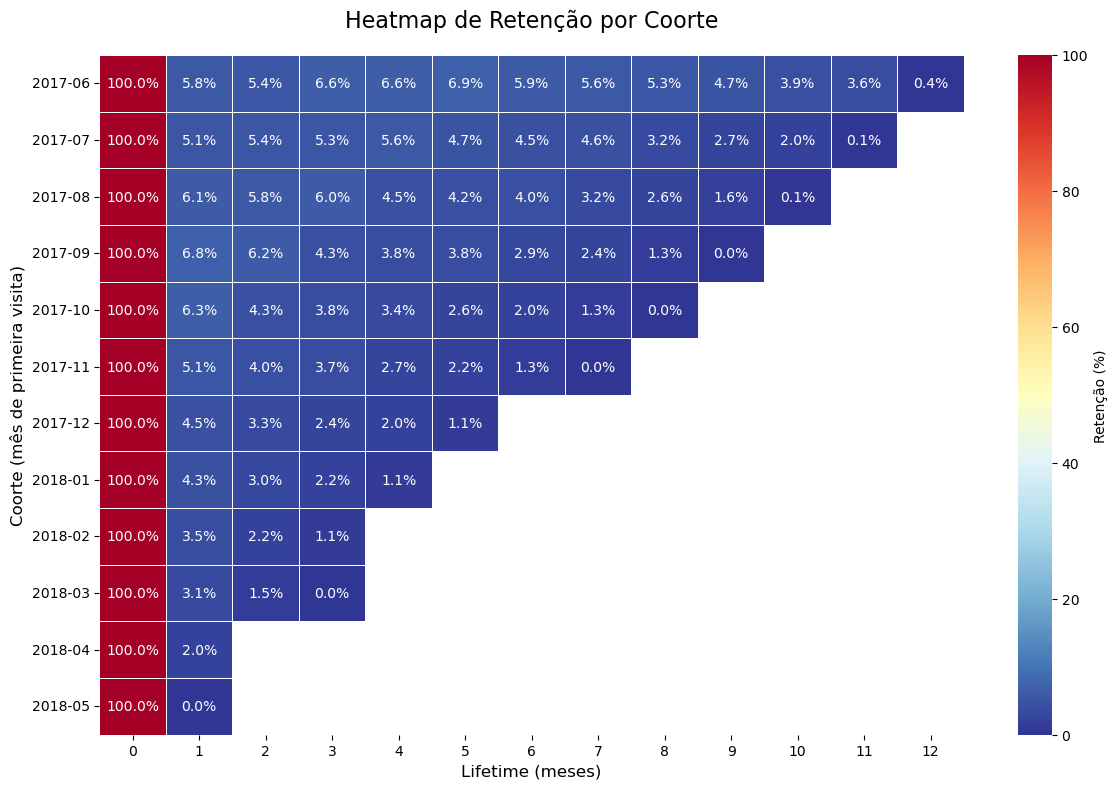

In [41]:
# Convertendo para porcentagem para melhor visualização
retention_pivot_percent = retention_pivot * 100

# Criando função para formatar com símbolo de %
def format_percent(val):
    return f'{val:.1f}%'

# Heatmap com símbolo de %:
plt.figure(figsize=(12, 8))
sns.heatmap(retention_pivot_percent,
            annot=True,
            fmt='.1f',               # 1 casa decimal
            cmap='RdYlBu_r',         # Paleta que vai do azul escuro ao claro
            cbar_kws={'label': 'Retenção (%)'},
            linewidths=0.5,
            linecolor='white',
            square=False,            # Células retangulares
            vmin=0,                  # Valor mínimo para escala de cores
            annot_kws={'size': 10})  # Tamanho da fonte dos números

# Adicionando % manualmente às anotações
ax = plt.gca()
for text in ax.texts:
    text.set_text(text.get_text() + '%')

plt.title('Heatmap de Retenção por Coorte', 
          fontsize=16, pad=20)
plt.xlabel('Lifetime (meses)', fontsize=12)
plt.ylabel('Coorte (mês de primeira visita)', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Conclusões:

- Eita! temos usuários que fizeram mais de 100 visitas ao site, com o intervalo entre as visitas de no máximo 1 hora (independente do dispositivo). De três uma:
Ou ele está usando um bot pra tentar conseguir informações ou hackear a empresa, ou ele não dorme (são mais de 10 dias de acesso continuo), ou existe alguma anomalia no sistema. Isso deve ser repassado à equipe.

- A resposta para a pergunta "Com que frequência os usuários voltam?" é 1 hora. Mas metade dos usuários retornam depois de 128 horas, o que pode ser uma informação importante.

- A retenção de usuários apresenta um padrão de declínio consistente, com as coortes mais antigas (2017-06 a 2017-08) mantendo taxas de retenção superiores a 6% no primeiro mês, enquanto as coortes mais recentes (2018-03 a 2018-05) mostram retenção drasticamente menor, chegando a 0% já no segundo mês. O gráfico revela que a empresa perdeu significativamente sua capacidade de reter usuários ao longo do tempo, com a retenção caindo de forma acentuada após o primeiro mês para todas as coortes.

## 2.2. As vendas;

### 2.2.1 Quando as pessoas começam a comprar?

Estamos interessados em saber o período de tempo entre o registro e a conversão - quando o usuário se torna um cliente. Por exemplo, se o registro e a primeira compra de um usuário ocorrem no mesmo dia, ele pode encaixar na categoria de Conversão 0d. Se a compra é realizada no dia seguinte, isso será a Conversão 1d.

In [42]:
# Precisamos encontrar o momento do primeiro pedido de cada usuário:
orders_copy = orders.copy()

pedidos = orders_copy.groupby('uid')['buy_ts'].min().reset_index().rename(columns = {'buy_ts':'primeiro_pedido'})

orders_copy = orders_copy.merge(
    pedidos,
    on = 'uid'
)

orders_copy.head()

,buy_ts,revenue,uid,primeiro_pedido
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01 00:10:00
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01 00:25:00
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01 00:27:00
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06-01 00:29:00
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06-01 07:58:00


In [43]:
# Vamos juntar essas informações com as informações de primeiro acesso (registro):
# Juntando e fatiando os dados que nos interessam em visits
visits_and_orders_dates = visits.merge(orders_copy, on = 'uid')[['device','uid', 'primeiro_acesso','primeiro_pedido']]

visits_and_orders_dates.head() # Esse dataframe contém todas as datas de primeiros acessos e pedidos para cada usuário. Algumas linhas podem está duplicadas
# vamos resolver isso:
visits_and_orders_dates = visits_and_orders_dates.drop_duplicates().reset_index(drop = True)

visits_and_orders_dates.head()

,device,uid,primeiro_acesso,primeiro_pedido
0,desktop,16174680259334210214,2018-03,2018-03-09 20:25:00
1,desktop,16007536194108375387,2017-09,2017-09-04 12:46:00
2,desktop,8056418121947262981,2017-06,2017-06-25 08:54:00
3,touch,18188358787673499603,2018-02,2018-02-12 19:48:00
4,desktop,2307401184189569202,2017-09,2017-09-27 09:23:00


In [44]:
# Vamos calcular o tempo_revenue: tempo para o primeiro pedido de cada usuário:

visits_and_orders_dates['primeiro_acesso_dt'] = visits_and_orders_dates['primeiro_acesso'].dt.to_timestamp()
visits_and_orders_dates['tempo_revenue'] = (
    visits_and_orders_dates['primeiro_pedido'] - visits_and_orders_dates['primeiro_acesso_dt']
)

# Convertendo para minutos:
visits_and_orders_dates['tempo_revenue'] = visits_and_orders_dates['tempo_revenue'].dt.total_seconds() / 60

visits_and_orders_dates.head()

,device,uid,primeiro_acesso,primeiro_pedido,primeiro_acesso_dt,tempo_revenue
0,desktop,16174680259334210214,2018-03,2018-03-09 20:25:00,2018-03-01,12745.0
1,desktop,16007536194108375387,2017-09,2017-09-04 12:46:00,2017-09-01,5086.0
2,desktop,8056418121947262981,2017-06,2017-06-25 08:54:00,2017-06-01,35094.0
3,touch,18188358787673499603,2018-02,2018-02-12 19:48:00,2018-02-01,17028.0
4,desktop,2307401184189569202,2017-09,2017-09-27 09:23:00,2017-09-01,38003.0


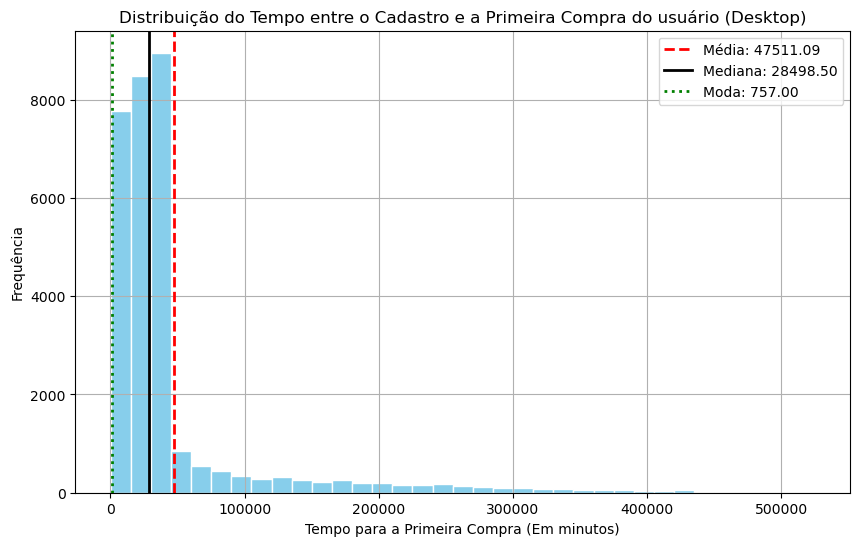

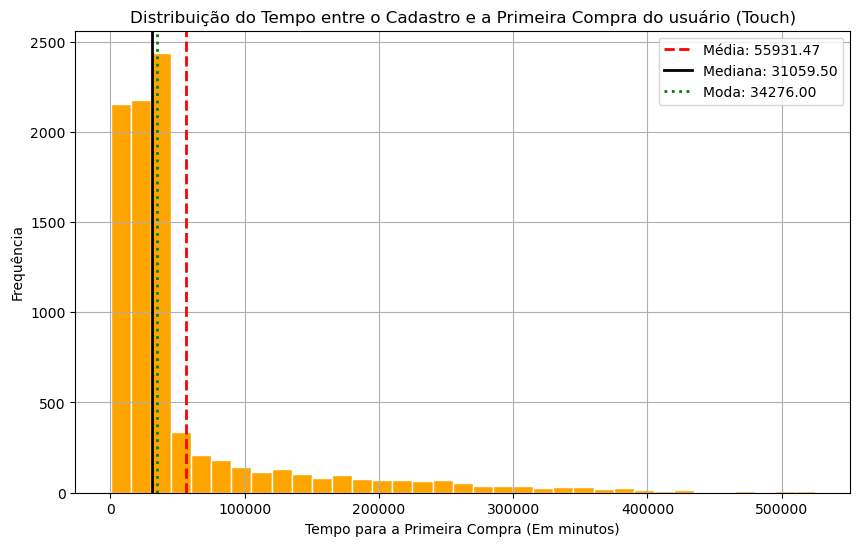

In [45]:
# Observando a distribuição dos valores da coluna 'tempo_revenue' por dispositivo:
time_desktop = visits_and_orders_dates[visits_and_orders_dates['device'] == 'desktop']
time_touch = visits_and_orders_dates[visits_and_orders_dates['device'] == 'touch']


# desktop
mean_val_desk = time_desktop['tempo_revenue'].mean()
median_val_desk = time_desktop['tempo_revenue'].median()
mode_val_desk = time_desktop['tempo_revenue'].mode()[0] # Pegamos o primeiro valor da moda

plt.figure(figsize=(10, 6))
time_desktop['tempo_revenue'].hist(bins=35, color='skyblue', edgecolor='white')

plt.axvline(mean_val_desk, color='red', linestyle='--', linewidth=2)
plt.axvline(median_val_desk, color='black', linestyle='-', linewidth=2)
plt.axvline(mode_val_desk, color='green', linestyle=':', linewidth=2)

legend_elements = [
    Line2D([0], [0], color='red', lw=2, ls='--', label=f'Média: {mean_val_desk:.2f}'),
    Line2D([0], [0], color='black', lw=2, ls='-', label=f'Mediana: {median_val_desk:.2f}'),
    Line2D([0], [0], color='green', lw=2, ls=':', label=f'Moda: {mode_val_desk:.2f}')
]

plt.legend(handles=legend_elements)

plt.title('Distribuição do Tempo entre o Cadastro e a Primeira Compra do usuário (Desktop)')
plt.xlabel('Tempo para a Primeira Compra (Em minutos)')
plt.ylabel('Frequência')

plt.show()


# touch
mean_val = time_touch['tempo_revenue'].mean()
median_val = time_touch['tempo_revenue'].median()
mode_val = time_touch['tempo_revenue'].mode()[0] # Pegamos o primeiro valor da moda

plt.figure(figsize=(10, 6))
time_touch['tempo_revenue'].hist(bins=35, color='orange', edgecolor='white')

plt.axvline(mean_val, color='red', linestyle='--', linewidth=2)
plt.axvline(median_val, color='black', linestyle='-', linewidth=2)
plt.axvline(mode_val, color='green', linestyle=':', linewidth=2)

legend_elements = [
    Line2D([0], [0], color='red', lw=2, ls='--', label=f'Média: {mean_val:.2f}'),
    Line2D([0], [0], color='black', lw=2, ls='-', label=f'Mediana: {median_val:.2f}'),
    Line2D([0], [0], color='green', lw=2, ls=':', label=f'Moda: {mode_val:.2f}')
]

plt.legend(handles=legend_elements)

plt.title('Distribuição do Tempo entre o Cadastro e a Primeira Compra do usuário (Touch)')
plt.xlabel('Tempo para a Primeira Compra (Em minutos)')
plt.ylabel('Frequência')

plt.show()



Novamente temos uma grande assimetria dos nossos dados. Para esse caso, escolheremos a mediana pelos seguintes motivos:

Mais relevante para o negócio:
- Planejamento de campanhas: Saber quando metade dos usuários converte
- Expectativas realistas: Tempo típico de conversão
- Benchmarks: Comparar com outros períodos ou canais

In [46]:
print(f'Normalmente as pessoas começam a comprar em {int(median_val)} minutos após o registro em dispositivos touch, e {int(median_val_desk)} minutos após o registro em desktops ')

Normalmente as pessoas começam a comprar em 31059 minutos após o registro em dispositivos touch, e 28498 minutos após o registro em desktops 


Conclusão:

- Normalmente as pessoas começam a comprar em 55 minutos após o registro em dispositivos touch, e 16 minutos após o registro em desktops, ou seja: Conversão 0D.

- Além disso, uma grande quantidade de pessoas costumam comprar praticamente logo após o registro, em 1 minuto (moda = 1 minuto) em desktops.

In [47]:
# Vamos fazer uma análise mais aprofundada a respeito desse assunto (O objetivo é fazer uma análise por cohorts de registro - data de primeiro acesso, por categoria de conversão - 0D, 1D, 2-7D, 8-30D, 30D+):
visits_and_orders_dates['primeiro_acesso'] = visits_and_orders_dates['primeiro_acesso'].dt.to_timestamp()

visits_and_orders_dates['primeiro_acesso'] = visits_and_orders_dates['primeiro_acesso'].dt.to_period('M') # convertendo o primeiro acesso para mes

visits_and_orders_dates['tempo_revenue_days'] = (visits_and_orders_dates['tempo_revenue']/1440).round(0) # convertendo 'tempo_revenue' para dia (cada dia tem 1440 minutos = 24 x 60)

# essa função será usada para categorizar o tempo de conversão: 
def categorizar_conversao(dias):
    if dias == 0:
        return '0d (mesmo dia)'
    elif dias == 1:
        return '1d'
    elif 2 <= dias <= 7:
        return '2-7d'
    elif 8 <= dias <= 30:
        return '8-30d'
    else:
        return '30d+'

# Aplicando a função na coluna 'tempo_revenue_days':
visits_and_orders_dates['tempo_revenue_category'] = visits_and_orders_dates['tempo_revenue_days'].apply(categorizar_conversao)

visits_and_orders_dates.head()


,device,uid,primeiro_acesso,primeiro_pedido,primeiro_acesso_dt,tempo_revenue,tempo_revenue_days,tempo_revenue_category
0,desktop,16174680259334210214,2018-03,2018-03-09 20:25:00,2018-03-01,12745.0,9.0,8-30d
1,desktop,16007536194108375387,2017-09,2017-09-04 12:46:00,2017-09-01,5086.0,4.0,2-7d
2,desktop,8056418121947262981,2017-06,2017-06-25 08:54:00,2017-06-01,35094.0,24.0,8-30d
3,touch,18188358787673499603,2018-02,2018-02-12 19:48:00,2018-02-01,17028.0,12.0,8-30d
4,desktop,2307401184189569202,2017-09,2017-09-27 09:23:00,2017-09-01,38003.0,26.0,8-30d


In [48]:
# atualizando as segmentações:
time_desktop = visits_and_orders_dates[visits_and_orders_dates['device'] == 'desktop']
time_touch = visits_and_orders_dates[visits_and_orders_dates['device'] == 'touch']

In [49]:
# Agregando para saber a quantidade de usuários por coorte e categoria
conversao_desktop = time_desktop.groupby(['primeiro_acesso','tempo_revenue_category'])['uid'].count().reset_index()
conversao_desktop.head()

,primeiro_acesso,tempo_revenue_category,uid
0,2017-06,0d (mesmo dia),22
1,2017-06,1d,83
2,2017-06,2-7d,625
3,2017-06,30d+,803
4,2017-06,8-30d,1038


In [50]:
conversao_touch = time_touch.groupby(['primeiro_acesso','tempo_revenue_category'])['uid'].count().reset_index()
conversao_touch.head()

,primeiro_acesso,tempo_revenue_category,uid
0,2017-06,0d (mesmo dia),2
1,2017-06,1d,22
2,2017-06,2-7d,150
3,2017-06,30d+,340
4,2017-06,8-30d,282


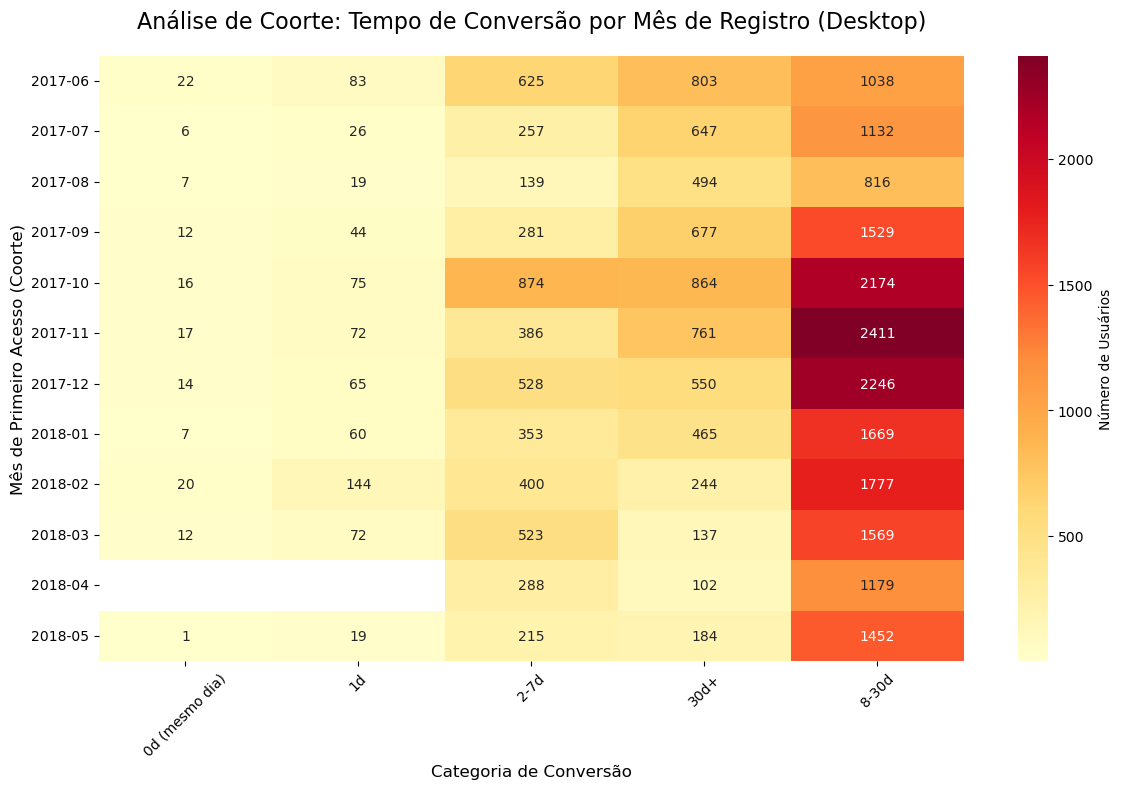

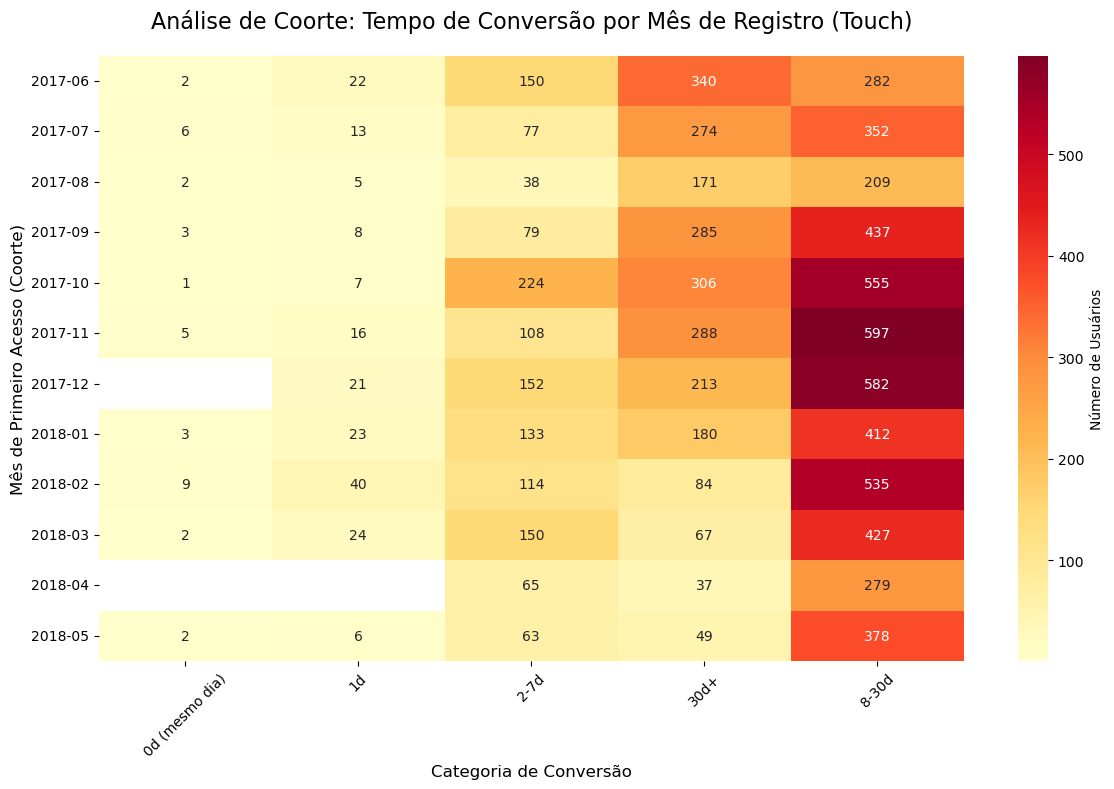

In [51]:
# Criando um headmap para visualizar os dados:

# ___________desktop____________:

# Fazendo uma tabela dinâmica com os resultados:
conversao_per_category = conversao_desktop.pivot_table(
    index = 'primeiro_acesso',
    columns = 'tempo_revenue_category',
    values = 'uid'
)

plt.figure(figsize=(12, 8))

# Criando o heatmap
sns.heatmap(conversao_per_category, 
            annot=True,           # Mostra os valores nas células
            fmt='.0f',            # Formato dos números (sem decimais)
            cmap='YlOrRd',        # Paleta de cores
            cbar_kws={'label': 'Número de Usuários'})

plt.title('Análise de Coorte: Tempo de Conversão por Mês de Registro (Desktop)', 
          fontsize=16, pad=20)
plt.xlabel('Categoria de Conversão', fontsize=12)
plt.ylabel('Mês de Primeiro Acesso (Coorte)', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# __________touch____________:

# Fazendo uma tabela dinâmica com os resultados:
conversao_per_category_touch = conversao_touch.pivot_table(
    index = 'primeiro_acesso',
    columns = 'tempo_revenue_category',
    values = 'uid'
)

plt.figure(figsize=(12, 8))

# Criando o heatmap
sns.heatmap(conversao_per_category_touch, 
            annot=True,           # Mostra os valores nas células
            fmt='.0f',            # Formato dos números (sem decimais)
            cmap='YlOrRd',        # Paleta de cores
            cbar_kws={'label': 'Número de Usuários'})

plt.title('Análise de Coorte: Tempo de Conversão por Mês de Registro (Touch)', 
          fontsize=16, pad=20)
plt.xlabel('Categoria de Conversão', fontsize=12)
plt.ylabel('Mês de Primeiro Acesso (Coorte)', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Conclusão da Análise de Conversão:

🎯 **Padrão de Conversão Dominante (8-30 dias)**
* **Concentração de Volume:** A categoria **8-30d** representa de longe a maior parte das conversões em ambos os dispositivos, variando de **1.179 a 2.411** conversões por coorte no Desktop e de **205 a 597** no Touch.
* **Contraste com o Tempo Médio/Mediano:** Embora as distribuições gerais mostrem picos de frequência concentrados nos primeiros minutos/dias logo após o cadastro (com modas e medianas baixas, próximas a 28 mil a 31 mil minutos, equivalentes a ~20 a 22 dias), a visão agregada por coorte comprova que o volume acumulado de conversões de longo prazo se expande fortemente na janela de 8 a 30 dias.

📈 **Sazonalidade e Pico de Performance**
* **Pico Histórico (Outubro a Dezembro de 2017):** O período entre **outubro e dezembro de 2017** registrou o maior volume de conversões de toda a série histórica para ambos os canais.
  * O **Desktop** atingiu seu recorde máximo na faixa de 8-30 dias em **novembro/2017**, com **2.411 conversões** (seguido de perto por dezembro/2017 com 2.246).
  * O **Touch** também teve seu ápice na mesma faixa (8-30d) em **novembro/2017**, alcançando **597 conversões**.
* **Comportamento no Dia 0 (0d):** Diferente de leituras superficiais, as conversões instantâneas no mesmo dia (`0d`) representam volumes muito baixos na coorte (geralmente abaixo de 20 conversões no Desktop e inferiores a 10 no Touch por coorte), indicando que a jornada de decisão do usuário exige um período considerável de maturação antes da primeira compra.

📉 **Tendência Temporal**
* **Estabilização e Redução em 2018:** A partir do início de 2018, observa-se uma desaceleração gradual no volume total de conversões mensais em todas as faixas temporais, refletindo possíveis variações no tráfego de novos cadastros ou mudanças no comportamento de aquisição dos usuários ao longo do tempo.

### 2.2.2 Quantos pedidos os clientes fazem durante um determinado período de tempo?

In [52]:
# Primeiro, vamos adicionar informação de dispositivo aos pedidos
# Pegando o dispositivo da primeira visita de cada usuário
device_info = visits.groupby('uid')['device'].first().reset_index()

# Juntando com orders_copy
orders_copy = orders_copy.merge(device_info, on='uid', how='left')

orders_copy['mes_da_compra'] = orders_copy['buy_ts'].dt.to_period('M')

In [53]:
# Agrupando por usuário e dispositivo:
# Garantindo que exista apenas uma coluna de dispositivo
if 'device' not in orders_copy.columns:
    device_info = visits.groupby('uid', observed=True)['device'].first().reset_index()
    orders_copy = orders_copy.merge(device_info, on='uid', how='left')

elif 'device_x' in orders_copy.columns or 'device_y' in orders_copy.columns:
    orders_copy['device'] = (
        orders_copy.get('device_y', orders_copy.get('device_x'))
        .fillna(orders_copy.get('device_x'))
    )
    orders_copy = orders_copy.drop(
        columns=[col for col in ['device_x', 'device_y'] if col in orders_copy.columns]
    )

# Agrupando pedidos por usuário e dispositivo
users_by_device = (
    orders_copy
    .groupby(['uid', 'device'], observed=True)['buy_ts']
    .count()
    .reset_index()
)

# Estatísticas por dispositivo
print("=== PEDIDOS POR CLIENTE SEGMENTADO POR DISPOSITIVO ===")
print("\n📱 DESKTOP:")
users_desktop = users_by_device[users_by_device['device'] == 'desktop']['buy_ts']
print(users_desktop.describe())

print("\n📱 TOUCH:")
users_touch = users_by_device[users_by_device['device'] == 'touch']['buy_ts']
print(users_touch.describe())

=== PEDIDOS POR CLIENTE SEGMENTADO POR DISPOSITIVO ===

📱 DESKTOP:
count    29222.000000
mean         1.399767
std          3.813892
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        239.000000
Name: buy_ts, dtype: float64

📱 TOUCH:
count    7301.000000
mean        1.302698
std         1.212438
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        45.000000
Name: buy_ts, dtype: float64


In [54]:
# Agrupando por usuário, mês e dispositivo:
users_and_month_device = orders_copy.groupby(['uid', 'mes_da_compra', 'device'])['buy_ts'].count().reset_index()

# Estatísticas mensais por dispositivo
print("\n=== PEDIDOS MENSAIS POR CLIENTE E DISPOSITIVO ===")
print("\n📱 DESKTOP:")
monthly_desktop = users_and_month_device[users_and_month_device['device'] == 'desktop']['buy_ts']
print(monthly_desktop.describe())

print("\n📱 TOUCH:")
monthly_touch = users_and_month_device[users_and_month_device['device'] == 'touch']['buy_ts']
print(monthly_touch.describe())


=== PEDIDOS MENSAIS POR CLIENTE E DISPOSITIVO ===

📱 DESKTOP:
count    474799.000000
mean          0.086150
std           0.504939
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          67.000000
Name: buy_ts, dtype: float64

📱 TOUCH:
count    474799.000000
mean          0.020032
std           0.182631
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          28.000000
Name: buy_ts, dtype: float64


C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_23004\2995402749.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



copnclusão:

- Cada cliente faz em média 1 compra em toda a sua vida (independente do dispositivo);
- Cada cliente faz em média 1 compra por mês (independente do dispositivo);

Parece que precisamos trabalhar a retenção

### 2.2.3 Qual é o volume médio de uma compra?

In [55]:
avg_revenue = orders_copy.groupby('device')['revenue'].mean().reset_index()

print(f'O volume médio de uma compra por dispositivo é de aproximadamente:')

print(avg_revenue)

O volume médio de uma compra por dispositivo é de aproximadamente:
    device   revenue
0  desktop  5.171421
1    touch  4.260897


C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_23004\2404334218.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



Conclusão:

O ticket médio do desktop é de $5,17 dólares, maior que o tickt médio de dispositivos touch

### 2.2.4 Quanto dinheiro eles trazem para a empresa (LTV)?

In [56]:
# LTV = o que cada cliente retorna em um determinado periodo de vida na empresa

# Vamos Calcular o LTV por Coortes Mensais (referente a primeira compra do usuário):

# Precisamos mexer na estrutura do nosso dataframe
orders_copy.head(3)


,buy_ts,revenue,uid,primeiro_pedido,device,mes_da_compra
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01 00:10:00,desktop,2017-06
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01 00:25:00,desktop,2017-06
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01 00:27:00,desktop,2017-06


In [57]:
# calculando a coluna 'lifetime'
orders_copy['lifetime'] = orders_copy['buy_ts'] - orders_copy['primeiro_pedido']

# convertendo 'primeiro_pedido' para mes:
orders_copy['primeiro_pedido'] = orders_copy['primeiro_pedido'].dt.to_period('M')

# convertendo 'lifetime' para mes:
orders_copy['lifetime'] = orders_copy['lifetime'].dt.days
orders_copy['lifetime'] = (orders_copy['lifetime']/30).round(0)

orders_copy.head(3)

,buy_ts,revenue,uid,primeiro_pedido,device,mes_da_compra,lifetime
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06,desktop,2017-06,0.0
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06,desktop,2017-06,0.0
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06,desktop,2017-06,0.0


In [58]:
# Para calcular o LTV, precisamos apenas saber quantos clietes compraram e o volume de compra (agregados por mes de 
# primeiro pedido e mes de vida - lifetime)

qtdd_users = orders_copy.groupby(['primeiro_pedido','lifetime','device'])['uid'].count().reset_index()

volume = orders_copy.groupby(['primeiro_pedido','lifetime','device'])['revenue'].sum().reset_index()


C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_23004\1909078055.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_23004\1909078055.py:6: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [59]:
# Vamos juntar essas informações:
life_time_value = qtdd_users.merge(
    volume,
    on = ['primeiro_pedido','lifetime','device']
).rename(columns = {'primeiro_pedido':'coorte_mensal_de_prim_compra'})

life_time_value.head()

,coorte_mensal_de_prim_compra,lifetime,device,uid,revenue
0,2017-06,0.0,desktop,1963,8171.62
1,2017-06,0.0,touch,393,1453.36
2,2017-06,1.0,desktop,132,716.30
3,2017-06,1.0,touch,12,54.16
4,2017-06,2.0,desktop,143,728.25


In [60]:
# Vamos agora calcular o LTV:
life_time_value['ltv'] = life_time_value['revenue']/life_time_value['uid']

life_time_value.head()

,coorte_mensal_de_prim_compra,lifetime,device,uid,revenue,ltv
0,2017-06,0.0,desktop,1963,8171.62,4.162822
1,2017-06,0.0,touch,393,1453.36,3.698117
2,2017-06,1.0,desktop,132,716.30,5.426515
3,2017-06,1.0,touch,12,54.16,4.513333
4,2017-06,2.0,desktop,143,728.25,5.092657


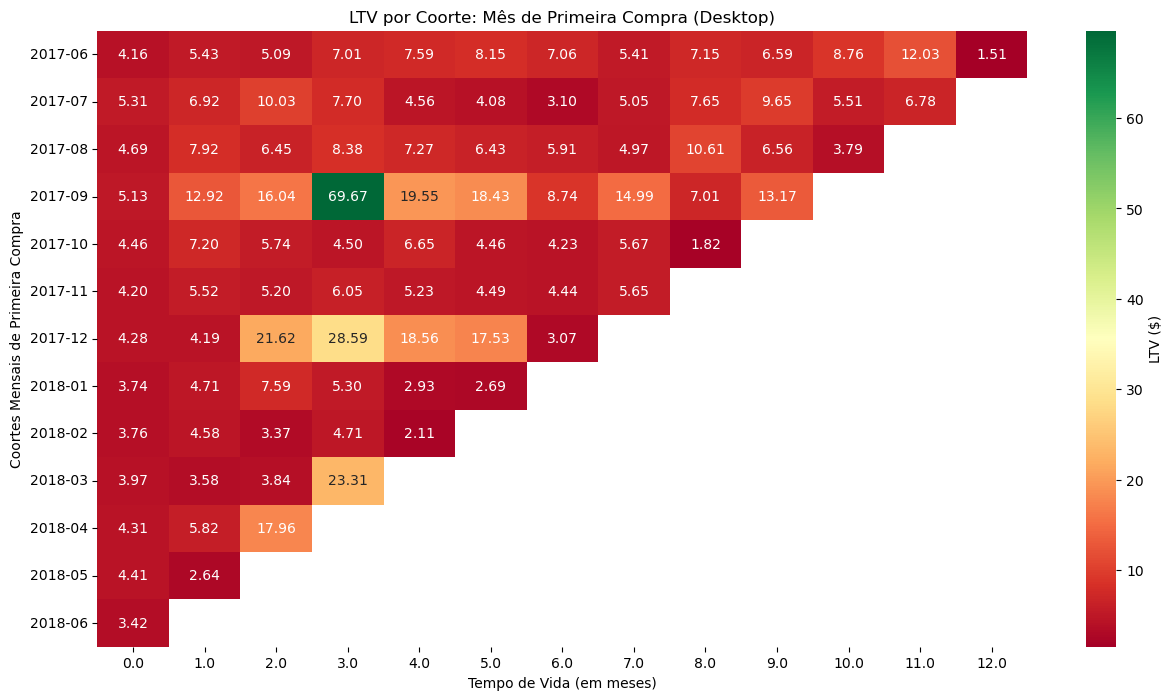

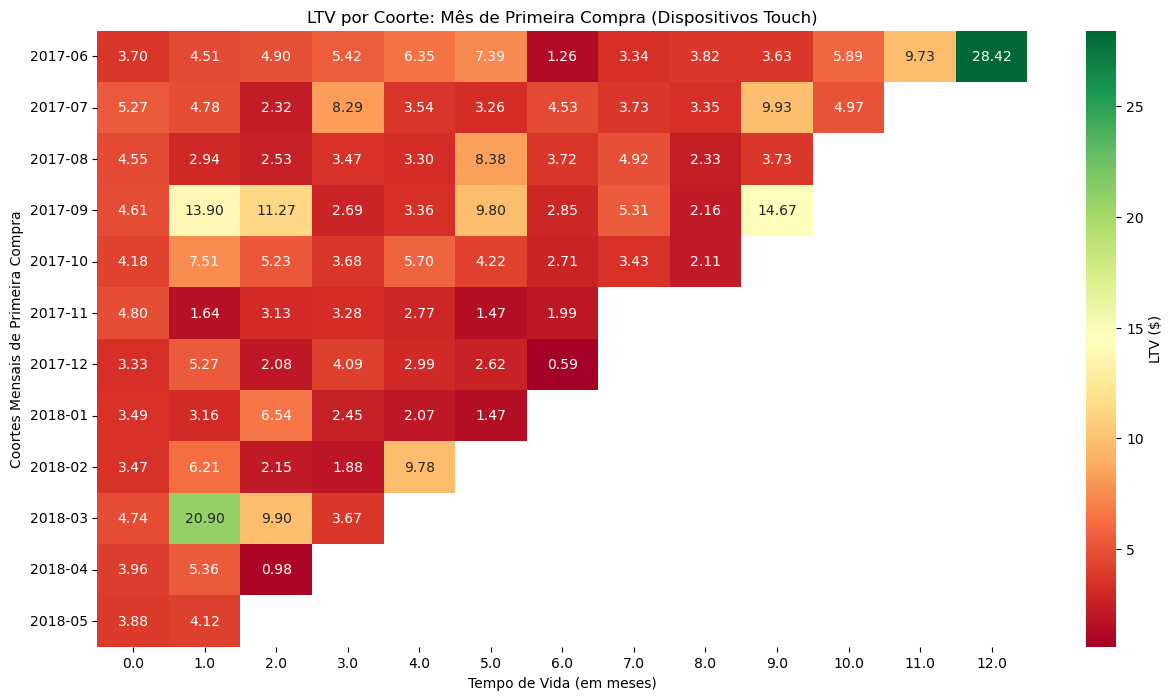

In [61]:
# preparando os dados para o heatmap:

desktop = life_time_value[life_time_value['device'] == 'desktop']
touch = life_time_value[life_time_value['device'] == 'touch']


# _____________desktop:____________
ltv_pivot = desktop.pivot_table(
    index = 'coorte_mensal_de_prim_compra',
    columns = 'lifetime',
    values = 'ltv'
)

# Para visualização, usaremos o heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(ltv_pivot, 
            annot=True, 
            fmt='.2f',
            cmap='RdYlGn',
            cbar_kws={'label': 'LTV ($)'})
plt.title('LTV por Coorte: Mês de Primeira Compra (Desktop)')
plt.xlabel('Tempo de Vida (em meses)')
plt.ylabel('Coortes Mensais de Primeira Compra')
plt.show()

# _____________touch:____________
ltv_pivot = touch.pivot_table(
    index = 'coorte_mensal_de_prim_compra',
    columns = 'lifetime',
    values = 'ltv'
)

# Para visualização, usaremos o heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(ltv_pivot, 
            annot=True, 
            fmt='.2f',
            cmap='RdYlGn',
            cbar_kws={'label': 'LTV ($)'})
plt.title('LTV por Coorte: Mês de Primeira Compra (Dispositivos Touch)')
plt.xlabel('Tempo de Vida (em meses)')
plt.ylabel('Coortes Mensais de Primeira Compra')
plt.show()

Conclusão da Análise de LTV (Desktop vs. Dispositivos Touch):

📊 **Crescimento Temporal Consistente**

* **LTV Inicial (Mês 0):** O valor gerado na primeira compra inicia-se em uma faixa muito estável e similar em ambos os canais, variando tipicamente entre **$3,40 e $5,30**.
* **Maturação e Retenção (Longo Prazo):** Observa-se um incremento gradual do LTV à medida que o tempo de vida do cliente avança. Casos de destaque ultrapassam a faixa de **$15 a $20+** (chegando a picos isolados expressivos de até **$69,67** no Desktop em coortes específicas).
* **Tendência de Acúmulo:** Há uma clareza visual de que clientes com maior tempo de base acumulam valor progressivamente, validando o impacto positivo das recompras na retenção.

📅 **Performance e Sazonalidade por Coorte**

* **O "Período Dourado" (Final de 2017):** As coortes iniciadas entre **setembro e dezembro de 2017** exibem as maiores expansões de LTV ao longo dos meses subsequentes, concentrando os maiores picos de valorização monetária da base.
* **Comportamento Inicial (Meados de 2017):** As coortes mais antigas do dataset (**2017-06 a 2017-08**) mantiveram um comportamento mais linear e conservador nos primeiros meses de vida, com saltos pontuais concentrados apenas em estágios mais avançados da retenção (por exemplo, no mês 12 para o Desktop e Touch).
* **Coortes de 2018:** Apresentam uma janela de observação reduzida devido ao corte temporal do estudo, limitando a visualização do ciclo de vida completo desses clientes mais recentes.

⚖️ **Comparativo entre Plataformas (Desktop vs. Touch)**

* **Equivalência de Padrões:** A estrutura das matrizes revela um comportamento financeiro bastante proporcional entre os dois canais, demonstrando que o valor extraído por cliente segue dinâmicas de consumo parecidas independentemente do dispositivo.
* **Disparidade de Escala de Cores:** Embora o teto da escala gráfica do Desktop alcance valores maiores ($69+ contra ~$28+ no Touch), a dinâmica de distribuição e o comportamento de expansão do LTV ao longo do tempo mantêm uma paridade operacional notável entre as plataformas.

## 2.3. O Marketing;

### 2.3.1 Quanto dinheiro foi gasto (No total/por origem/ao longo do tempo)? 

In [62]:
# No total

# Primeiro, vamos conectar os custos com as visitas para obter informação de dispositivo
# Agregando visitas por source_id, dispositivo e mês para calcular proporções
visitas_por_dispositivo = visits.groupby(['source_id', 'device', visits['start_ts'].dt.to_period('M')])['uid'].count().reset_index()
visitas_por_dispositivo = visitas_por_dispositivo.rename(columns={'start_ts': 'dt_mes', 'uid': 'total_visitas'})

# Calculando a proporção de visitas por dispositivo para cada canal/mês
proporcao_visitas = visitas_por_dispositivo.groupby(['source_id', 'dt_mes']).apply(
    lambda x: x.assign(proporcao=x['total_visitas'] / x['total_visitas'].sum())
).reset_index(drop=True)

# Juntando com os custos
custos_por_dispositivo = proporcao_visitas.merge(
    costs.groupby(['source_id', costs['dt'].dt.to_period('M')])['costs'].sum().reset_index().rename(columns={'dt': 'dt_mes'}),
    on=['source_id', 'dt_mes'],
    how='left'
)

# Calculando custos proporcionais por dispositivo
custos_por_dispositivo['costs_device'] = (custos_por_dispositivo['costs'] * custos_por_dispositivo['proporcao']).round(2)

# Agora podemos calcular o total por dispositivo
total_desktop = custos_por_dispositivo[custos_por_dispositivo['device'] == 'desktop']['costs_device'].sum()
total_touch = custos_por_dispositivo[custos_por_dispositivo['device'] == 'touch']['costs_device'].sum()
total_geral = custos_por_dispositivo['costs_device'].sum()

print(f'Foram gastos no total ${total_geral:.2f} com marketing')
print(f'  - Desktop: ${total_desktop:.2f} ({100*total_desktop/total_geral:.1f}%)')
print(f'  - Touch: ${total_touch:.2f} ({100*total_touch/total_geral:.1f}%)')

Foram gastos no total $329131.62 com marketing
  - Desktop: $244424.87 (74.3%)
  - Touch: $84706.75 (25.7%)


C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_23004\3133798671.py:5: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_23004\3133798671.py:9: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [63]:
# por origem

# por origem
# Calculando gastos por origem e dispositivo
origem_desktop = custos_por_dispositivo[custos_por_dispositivo['device'] == 'desktop'].groupby('source_id')['costs_device'].sum().reset_index()
origem_touch = custos_por_dispositivo[custos_por_dispositivo['device'] == 'touch'].groupby('source_id')['costs_device'].sum().reset_index()

# Criando um dicionário para descrever as origens como strings:
descricao = {
    1: 'Canal 1',
    2: 'Canal 2',
    3: 'Canal 3',
    4: 'Canal 4',
    5: 'Canal 5',
    9: 'Canal 9',
    10: 'Canal 10'
}

# Filtrando apenas source_ids válidos antes do mapeamento
origem_desktop = origem_desktop[origem_desktop['source_id'].isin(descricao.keys())].copy()
origem_touch = origem_touch[origem_touch['source_id'].isin(descricao.keys())].copy()

# Aplicando a descrição para desktop
origem_desktop['source_id'] = origem_desktop['source_id'].map(descricao)

# Gráfico para Desktop
fig_origem_desktop = px.bar(origem_desktop,
                    x='source_id',
                    y='costs_device',
                    title='Gastos por origem de Marketing - Desktop (Em $)',
                    labels={'source_id': 'Origem', 'costs_device': 'Custo ($)'},
                    color='source_id',  
                    color_discrete_sequence=px.colors.qualitative.Set3,
                    text=[f'{int(valor)}' for valor in origem_desktop['costs_device']])

fig_origem_desktop.update_traces(textposition='outside') 
fig_origem_desktop.update_layout(
    margin=dict(t=100), 
    yaxis=dict(range=[0, origem_desktop['costs_device'].max() * 1.1]) 
)
fig_origem_desktop.show()

# Aplicando a descrição para touch
origem_touch['source_id'] = origem_touch['source_id'].map(descricao)

# Gráfico para Touch
fig_origem_touch = px.bar(origem_touch,
                    x='source_id',
                    y='costs_device',
                    title='Gastos por origem de Marketing - Touch (Em $)',
                    labels={'source_id': 'Origem', 'costs_device': 'Custo ($)'},
                    color='source_id',  
                    color_discrete_sequence=px.colors.qualitative.Pastel1,
                    text=[f'{int(valor)}' for valor in origem_touch['costs_device']])

fig_origem_touch.update_traces(textposition='outside') 
fig_origem_touch.update_layout(
    margin=dict(t=100), 
    yaxis=dict(range=[0, origem_touch['costs_device'].max() * 1.1]) 
)
fig_origem_touch.show()

In [64]:
# ao longo do tempo (por mes)

# ao longo do tempo (por mes) segmentado por dispositivo
# Convertendo Period para datetime
custos_por_dispositivo['dt_mes_datetime'] = custos_por_dispositivo['dt_mes'].dt.to_timestamp()

tempo_dispositivo = custos_por_dispositivo.groupby(['dt_mes_datetime', 'device'])['costs_device'].sum().reset_index()

# Gráfico com linhas separadas para cada dispositivo
fig_tempo_dispositivo = px.line(tempo_dispositivo, 
                               x='dt_mes_datetime', 
                               y='costs_device',
                               color='device',
                               title='Gastos Mensais com Marketing por Dispositivo (Em $)', 
                               labels={'dt_mes_datetime': 'Mês', 'costs_device': 'Custo ($)', 'device': 'Dispositivo'},
                               color_discrete_map={'desktop': 'orange', 'touch': 'blue'})

fig_tempo_dispositivo.show()

C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_23004\3024914932.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



Conclusão:

- Desktop domina o investimento: Representa 74,3% do orçamento total ($244.424,87)
  
- Touch recebe menos recursos: Apenas 25,7% do orçamento ($84.706,75)

  
- Canal 3 lidera em ambos: Maior investimento tanto para desktop quanto touch ( Vamos ver se vai corresponder a altura)

  
- Concentração similar: Os mesmos 3 canais (1, 2 e 3) dominam o investimento em ambos os dispositivos

- Sazonalidade clara: Pico de investimento em novembro/dezembro 2017 (fim de ano)

  
- Desktop sempre superior: Linha laranja (desktop) consistentemente acima da azul (touch)

  
- Tendências paralelas: Ambos os dispositivos seguem o mesmo padrão temporal

  
- Declínio pós-2017: Redução gradual dos investimentos a partir de 2018


### 2.3.2 Quanto custou a aquisição de clientes para cada origem?

Vamos precisar usar o dataframe visits como ponte para unir as informações dos custos (costs) à aquisição de novos usuários (orders). Usando a chave 'Source Id'.

In [65]:
costs.head()

,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08


In [66]:
# Preparando dados de custos por origem e mês (mantemos igual)
costs['dt_mes'] = pd.to_datetime(costs['dt']).dt.to_period('M')

custos_origem_mes = costs.groupby(['source_id', 'dt_mes'])['costs'].sum().reset_index()

# Identificando novos CLIENTES por origem, dispositivo e mês
# Primeiro, vamos pegar a origem E dispositivo de cada cliente baseada na sua primeira visita
primeiro_acesso_origem_device = visits.groupby('uid').agg({
    'start_ts': 'min',
    'source_id': 'first',  # Origem da primeira visita
    'device': 'first'      # Dispositivo da primeira visita
}).reset_index()

# Pegando a primeira compra de cada cliente
primeira_compra = orders.groupby('uid').agg({
    'buy_ts': 'min',
    'revenue': 'sum'
}).reset_index()
primeira_compra = primeira_compra.rename(columns={'buy_ts': 'primeira_compra'})



In [67]:
# Juntando origem + dispositivo com primeira compra
novos_clientes_device = primeira_compra.merge(
    primeiro_acesso_origem_device[['uid', 'source_id', 'device']],
    on='uid',
    how='left'
)

# Criando coluna de mês da primeira compra
novos_clientes_device['dt_mes'] = (
    pd.to_datetime(novos_clientes_device['primeira_compra'])
    .dt.to_period('M')
)

# Agregando novos clientes por origem, dispositivo e mês
novos_clientes_origem_device_mes = novos_clientes_device.groupby(['source_id', 'device', 'dt_mes']).agg({
    'uid': 'count',
    'revenue': 'sum'
}).reset_index()
novos_clientes_origem_device_mes = novos_clientes_origem_device_mes.rename(columns={
    'uid': 'novos_clientes',
    'revenue': 'receita_novos_clientes'
})

print("Primeiros resultados por dispositivo:")
novos_clientes_origem_device_mes.head()

Primeiros resultados por dispositivo:


C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_23004\3641668406.py:15: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,source_id,device,dt_mes,novos_clientes,receita_novos_clientes
0,1,desktop,2017-06,169,6651.86
1,1,desktop,2017-07,172,3339.48
2,1,desktop,2017-08,111,936.13
3,1,desktop,2017-09,221,4173.97
4,1,desktop,2017-10,327,2969.62


In [68]:
# Para calcular CAC por dispositivo, precisamos distribuir os custos
# Vamos assumir que os custos são distribuídos proporcionalmente ao número de novos clientes por dispositivo

# Calculando a proporção de clientes por dispositivo para cada canal/mês
proporcao_device = novos_clientes_origem_device_mes.groupby(['source_id', 'dt_mes']).apply(
    lambda x: x.assign(proporcao=x['novos_clientes'] / x['novos_clientes'].sum())
).reset_index(drop=True)

# Juntando com os custos totais
marketing_device = proporcao_device.merge(
    custos_origem_mes,
    on=['source_id', 'dt_mes'],
    how='left'
)

# Calculando custos proporcionais por dispositivo
marketing_device['costs_device'] = (marketing_device['costs'] * marketing_device['proporcao']).round(2)

# Calculando CAC por dispositivo
marketing_device['cac_device'] = (marketing_device['costs_device'] / marketing_device['novos_clientes']).round(2)


marketing_device.head()


C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_23004\1225290765.py:5: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,source_id,device,dt_mes,novos_clientes,receita_novos_clientes,proporcao,costs,costs_device,cac_device
0,1,desktop,2017-06,169,6651.86,0.832512,1125.61,937.08,5.54
1,1,touch,2017-06,34,370.39,0.167488,1125.61,188.53,5.54
2,1,desktop,2017-07,172,3339.48,0.815166,1072.88,874.58,5.08
3,1,touch,2017-07,39,311.81,0.184834,1072.88,198.30,5.08
4,1,desktop,2017-08,111,936.13,0.765517,951.81,728.63,6.56


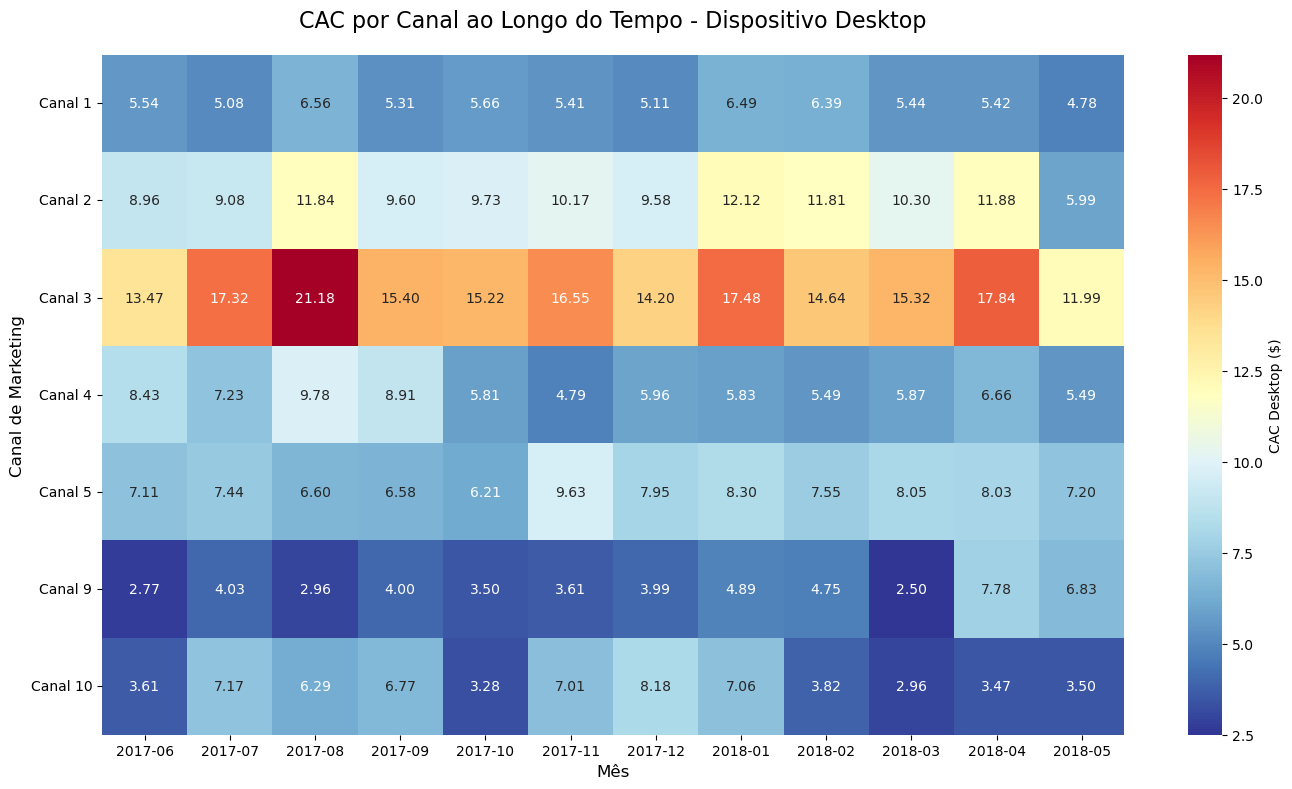

In [69]:
# Filtrando dados apenas para desktop
marketing_desktop = marketing_device[marketing_device['device'] == 'desktop'].copy()

# Mapeando os source_id para nomes mais descritivos
marketing_desktop['canal'] = marketing_desktop['source_id'].map({
    1: 'Canal 1',
    2: 'Canal 2', 
    3: 'Canal 3',
    4: 'Canal 4',
    5: 'Canal 5',
    9: 'Canal 9',
    10: 'Canal 10'
})

# Convertendo dt_mes para período mensal apenas se necessário
if not isinstance(marketing_desktop['dt_mes'].dtype, pd.PeriodDtype):
    marketing_desktop['dt_mes'] = (
        pd.to_datetime(marketing_desktop['dt_mes'])
        .dt.to_period('M')
    )

# Definindo a ordem desejada dos canais
ordem_canais = ['Canal 1', 'Canal 2', 'Canal 3', 'Canal 4', 'Canal 5', 'Canal 9', 'Canal 10']

# Criando a tabela dinâmica para desktop
cac_desktop_pivot = marketing_desktop.pivot_table(
    index='canal',
    columns='dt_mes',
    values='cac_device',
    fill_value=0
).reindex(ordem_canais)

# Criando o heatmap para desktop
plt.figure(figsize=(14, 8))
sns.heatmap(cac_desktop_pivot,
            annot=True,
            fmt='.2f',
            cmap='RdYlBu_r',
            cbar_kws={'label': 'CAC Desktop ($)'})
plt.title('CAC por Canal ao Longo do Tempo - Dispositivo Desktop', fontsize=16, pad=20)
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Canal de Marketing', fontsize=12)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

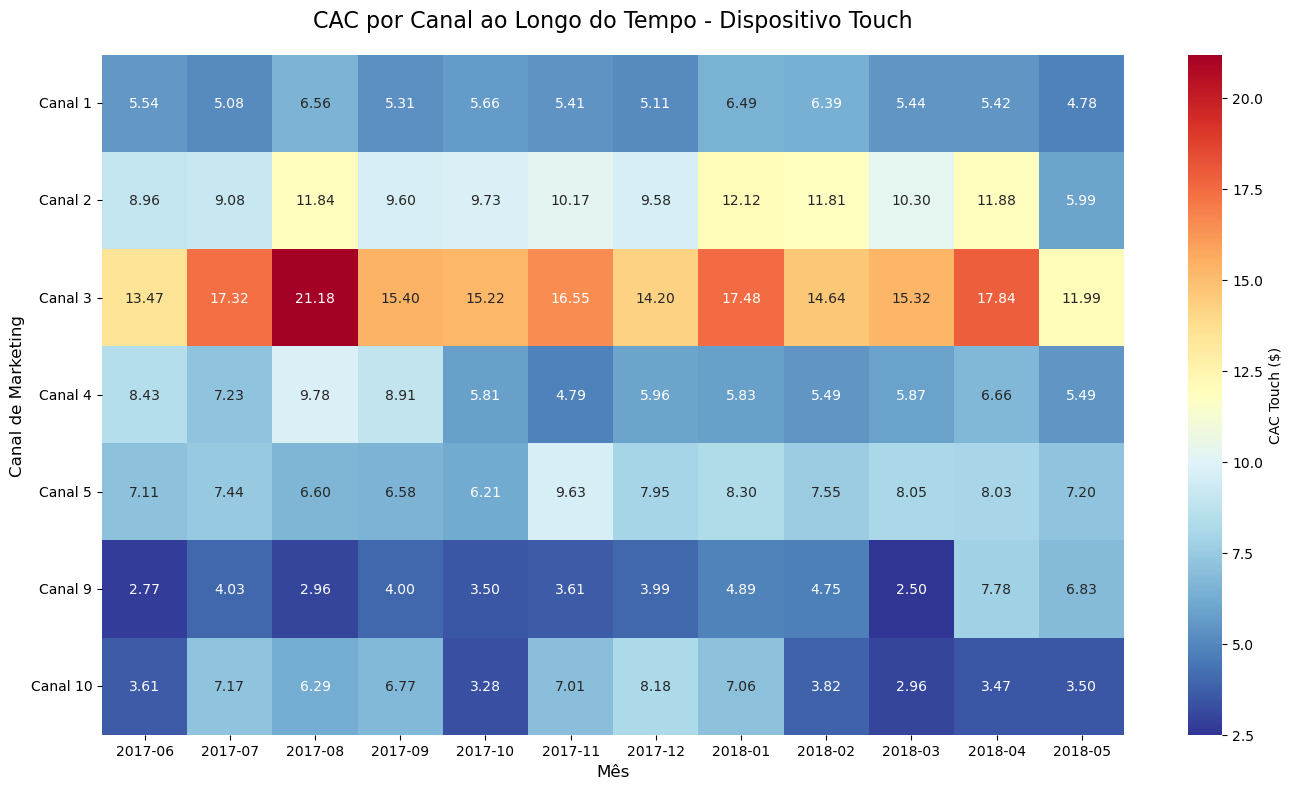

In [70]:
# Filtrando dados apenas para touch
marketing_touch = marketing_device[marketing_device['device'] == 'touch'].copy()

# Mapeando os source_id para nomes mais descritivos
marketing_touch['canal'] = marketing_touch['source_id'].map({
    1: 'Canal 1',
    2: 'Canal 2', 
    3: 'Canal 3',
    4: 'Canal 4',
    5: 'Canal 5',
    9: 'Canal 9',
    10: 'Canal 10'
})

# Convertendo dt_mes para período mensal apenas se necessário
if not isinstance(marketing_touch['dt_mes'].dtype, pd.PeriodDtype):
    marketing_touch['dt_mes'] = (
        pd.to_datetime(marketing_touch['dt_mes'])
        .dt.to_period('M')
    )

# Criando a tabela dinâmica para touch
cac_touch_pivot = marketing_touch.pivot_table(
    index='canal',
    columns='dt_mes', 
    values='cac_device',
    fill_value=0
).reindex(ordem_canais)

# Criando o heatmap para touch
plt.figure(figsize=(14, 8))
sns.heatmap(cac_touch_pivot,
            annot=True,
            fmt='.2f',
            cmap='RdYlBu_r',
            cbar_kws={'label': 'CAC Touch ($)'})
plt.title('CAC por Canal ao Longo do Tempo - Dispositivo Touch', fontsize=16, pad=20)
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Canal de Marketing', fontsize=12)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Conclusão:

 🖥️ CAC Desktop vs 📱 CAC Touch

Padrões Identificados:

💰 Custos de Aquisição Similares
- Observação Principal: Os valores de CAC são idênticos entre desktop e touch para cada canal/mês
- Motivo: Os custos foram distribuídos proporcionalmente ao número de clientes por dispositivo
- Implicação: A eficiência de conversão é similar entre os dispositivos

📈 Tendências Temporais Consistentes

Ambos os dispositivos mostram:

- Pico de CAC: Agosto 2017 (valores mais altos - cores mais vermelhas)
- Melhor Performance: Junho-Julho 2017 (CAC mais baixo - cores mais azuis)
- Deterioração: CAC aumentando ao longo de 2018

🎯 Performance por Canal

Canais Eficientes (CAC baixo):

- Canal 1 e 2: Consistentemente azuis (CAC ~$5-6)
- Performance estável em ambos os dispositivos
- Canais Problemáticos:

- Canal 3: CAC elevado em vários períodos (Foi o campeão em despesas para ambos os dispositivos. Vamos ver se o retorno vem a altura)
- Canal 4 e 5: Performance irregular
- Canais 9 e 10: Dados limitados, mas CAC variável Veremos mais na frente.

### 2.3.3 Os investimentos valeram a pena (ROI)? 

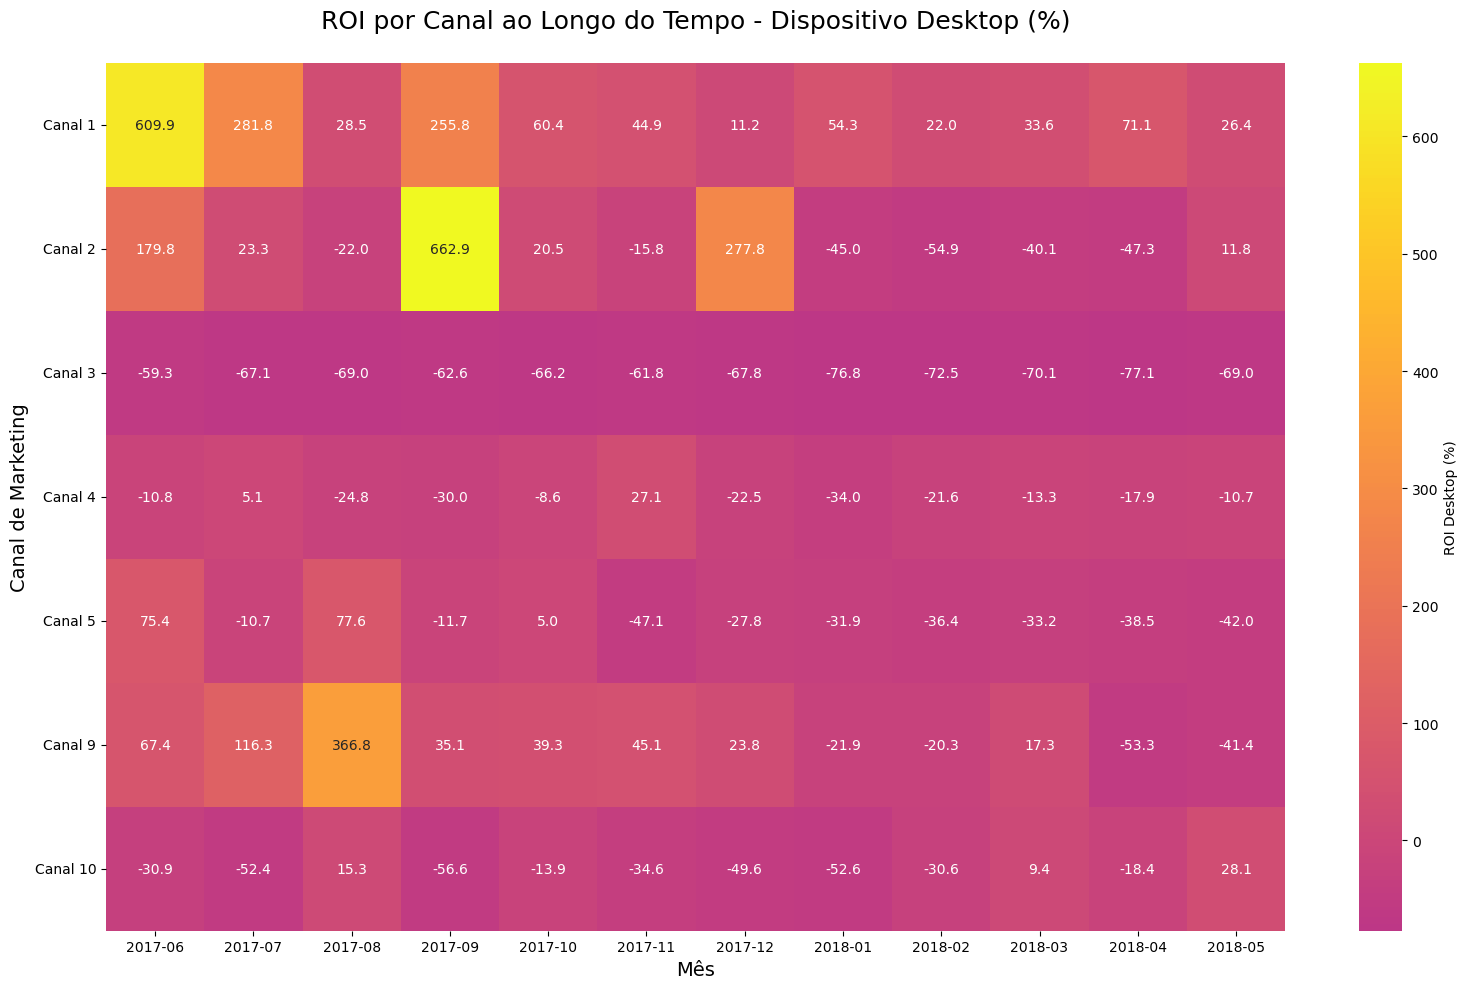

In [71]:
# Calculando ROI para dados segmentados por dispositivo
marketing_device['roi_device'] = (100 * (marketing_device['receita_novos_clientes'] - marketing_device['costs_device']) / marketing_device['costs_device']).round(2)

# Filtrando dados apenas para desktop
marketing_desktop_roi = marketing_device[marketing_device['device'] == 'desktop'].copy()

# Mapeando os source_id para nomes mais descritivos
marketing_desktop_roi['canal'] = marketing_desktop_roi['source_id'].map({
    1: 'Canal 1',
    2: 'Canal 2', 
    3: 'Canal 3',
    4: 'Canal 4',
    5: 'Canal 5',
    9: 'Canal 9',
    10: 'Canal 10'
})

# Convertendo dt_mes para period se necessário
if not isinstance(marketing_desktop_roi['dt_mes'].dtype, pd.PeriodDtype):
    marketing_desktop_roi['dt_mes'] = (
        pd.to_datetime(marketing_desktop_roi['dt_mes'])
        .dt.to_period('M')
    )

# Definindo a ordem desejada dos canais
ordem_canais = ['Canal 1', 'Canal 2', 'Canal 3', 'Canal 4', 'Canal 5', 'Canal 9', 'Canal 10']

# Criando a tabela dinâmica para ROI desktop
roi_desktop_pivot = marketing_desktop_roi.pivot_table(
    index='canal',
    columns='dt_mes',
    values='roi_device',
    fill_value=0
).reindex(ordem_canais)

# Criando o heatmap do ROI para desktop
plt.figure(figsize=(16, 10))
sns.heatmap(roi_desktop_pivot,
            annot=True,
            fmt='.1f',
            cmap='plasma',  
            center=0,       # Centro na cor neutra (ROI = 0%)
            cbar_kws={'label': 'ROI Desktop (%)'})
plt.title('ROI por Canal ao Longo do Tempo - Dispositivo Desktop (%)', fontsize=18, pad=25)
plt.xlabel('Mês', fontsize=14)
plt.ylabel('Canal de Marketing', fontsize=14)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

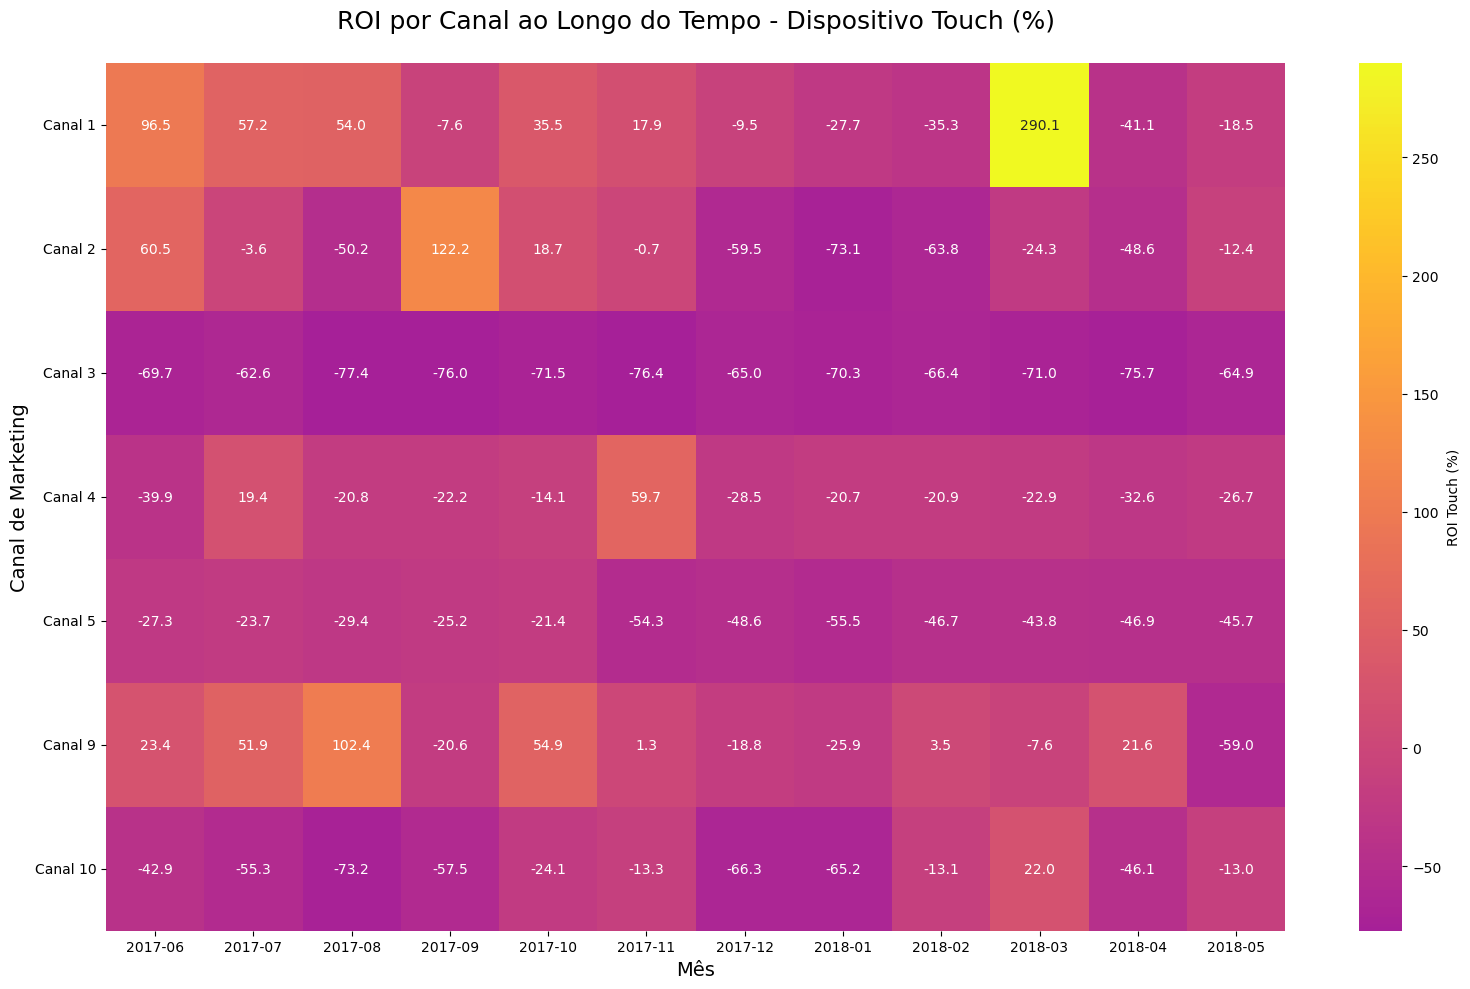

In [72]:
# Filtrando dados apenas para touch
marketing_touch_roi = marketing_device[marketing_device['device'] == 'touch'].copy()

# Mapeando os source_id para nomes mais descritivos
marketing_touch_roi['canal'] = marketing_touch_roi['source_id'].map({
    1: 'Canal 1',
    2: 'Canal 2', 
    3: 'Canal 3',
    4: 'Canal 4',
    5: 'Canal 5',
    9: 'Canal 9',
    10: 'Canal 10'
})

# Convertendo dt_mes para period se necessário
if not isinstance(marketing_touch_roi['dt_mes'].dtype, pd.PeriodDtype):
    marketing_touch_roi['dt_mes'] = (
        pd.to_datetime(marketing_touch_roi['dt_mes'])
        .dt.to_period('M')
    )

# Criando a tabela dinâmica para ROI touch
roi_touch_pivot = marketing_touch_roi.pivot_table(
    index='canal',
    columns='dt_mes',
    values='roi_device',
    fill_value=0
).reindex(ordem_canais)

# Criando o heatmap do ROI para touch
plt.figure(figsize=(16, 10))
sns.heatmap(roi_touch_pivot,
            annot=True,
            fmt='.1f',
            cmap='plasma',  
            center=0,       # Centro na cor neutra (ROI = 0%)
            cbar_kws={'label': 'ROI Touch (%)'})
plt.title('ROI por Canal ao Longo do Tempo - Dispositivo Touch (%)', fontsize=18, pad=25)
plt.xlabel('Mês', fontsize=14)
plt.ylabel('Canal de Marketing', fontsize=14)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Conclusão e Recomendações Estratégicas: ROI por Canal (Desktop vs. Touch):

1. **Performance Contrastante entre Canais**

* **Canal 1 (Destaque Positivo):** Apresentou uma performance altamente lucrativa, alcançando picos expressivos de **609.9%** de ROI no Desktop (Jun/2017) e **290.1%** no Touch (Mar/2018), consolidando-se como um dos principais geradores de retorno.
* **Canal 2 (Solidez e Picos Pontuais):** Demonstrou excelente eficiência em momentos específicos, como no Desktop em Set/2017 (**662.9%**) e no Touch em Set/2017 (**122.2%**), além de manter bons resultados em outros meses.
* **Canal 9 (Eficiência Sazonal):** Destacou-se positivamente em meados de 2017, atingindo **366.8%** no Desktop e **102.4%** no Touch em Ago/2017.
* **Canal 3 (Ineficiência Crítica):** Apresentou um ROI **majoritariamente negativo** de forma consistente ao longo de toda a série histórica em ambas as plataformas (frequentemente abaixo de -60% e -70%), configurando-se como um ralo de recursos que consome orçamento sem retorno proporcional.

---

2. **Declínio Temporal Evidente**

* **2017 (O Período de Ouro):** Caracterizado por picos de ROI expressivos e margens operacionais altamente saudáveis em vários canais (especialmente entre junho e novembro).
* **2018 (Queda Generalizada):** Observa-se uma desaceleração drástica na rentabilidade a partir do início de 2018, com a maioria dos canais (exceto picos isolados) operando em faixa negativa ou muito próxima de zero, sinalizando forte desgaste, saturação de mercado ou mudanças na dinâmica de aquisição.

---

3. **Comportamento entre Dispositivos (Desktop vs. Touch)**

* **Paridade de Padrões:** Os canais mantêm uma estrutura de comportamento de ROI muito parecida em ambas as plataformas — canais lucrativos no desktop tendem a performar melhor também no touch, enquanto os ineficientes acumulam prejuízos generalizados.
* **Consistência de Prejuízos:** O **Canal 3** repete o seu fracasso financeiro de forma idêntica tanto no Desktop quanto no Touch, reforçando que o problema reside na estratégia ou na segmentação do canal, e não na plataforma do utilizador.

---

💡 **Recomendações Estratégicas**

* **Realocação Radical de Orçamento:** Cortar ou reduzir drasticamente os investimentos no **Canal 3**, redirecionando o capital para canais validados e consistentes, como o **Canal 1 e Canal 2**.
* **Investigação do Canal 3:** Realizar uma auditoria profunda para entender os motivos de o canal apresentar retornos permanentemente negativos (problemas de público-alvo, criativos, atribuição ou proposta de valor).
* **Mitigação da Queda em 2018:** Analisar o que motivou a retração generalizada de eficiência a partir de 2018 para ajustar o *mix* de mídia antes de novas alocações em larga escala.

# 3. Conclusões e recomendações finais

## 3.1 Métricas analisadas

As principais conclusões foram construídas a partir de quatro dimensões da análise:

- **ROI:** para avaliar a rentabilidade dos investimentos de marketing por canal, dispositivo e período.
- **CAC:** para comparar o custo de aquisição de novos clientes entre os diferentes canais.
- **LTV:** para analisar quanto valor os clientes podem gerar ao longo do seu ciclo de vida.
- **Tempo até a primeira compra:** para compreender quanto tempo os usuários levam para realizar sua primeira conversão.

---



## 3.2 Principais descobertas

### 1. Canais 1 e 2 apresentam os melhores resultados de rentabilidade

Os Canais 1 e 2 se destacam entre as fontes analisadas, apresentando CAC relativamente baixo, em torno de **US$ 5–6** em diversos períodos, e alguns dos maiores ROIs observados.

O Canal 1 alcançou **609,9% de ROI no Desktop em junho de 2017**, enquanto o Canal 2 atingiu **662,9% no Desktop em setembro de 2017**.

O Canal 9 também apresentou bons resultados em determinados períodos de 2017, embora com comportamento mais sazonal e dados mais limitados.

Portanto, os resultados indicam que Canais 1 e 2 devem ser considerados referências importantes para a análise de eficiência das campanhas.

### 2. O Canal 3 apresenta baixa eficiência financeira

O Canal 3 recebeu o maior volume de investimento entre os canais analisados, tanto no Desktop quanto no Touch.

Apesar disso, apresentou **ROI majoritariamente negativo ao longo da série histórica**, frequentemente em níveis inferiores a -60% e -70%.

Esse comportamento aparece nos dois dispositivos, indicando que o problema não parece estar restrito à experiência de um determinado dispositivo.

O resultado justifica uma análise mais aprofundada do Canal 3 antes da manutenção ou expansão dos investimentos.

### 3. A eficiência do marketing sofreu deterioração em 2018

Os resultados mostram uma diferença importante entre 2017 e 2018.

Durante boa parte de 2017, especialmente entre junho e novembro, diversos canais apresentaram resultados positivos e picos elevados de ROI.

A partir de 2018, entretanto, observa-se uma **queda generalizada da rentabilidade**, acompanhada pelo aumento do CAC em relação aos períodos anteriores.

Essa mudança merece investigação para identificar se houve alterações no comportamento dos usuários, saturação das fontes de aquisição, mudanças nas campanhas ou outros fatores que possam explicar a deterioração.

### 4. Desktop e Touch apresentam padrões semelhantes

Apesar da diferença na participação do investimento — **74,3% no Desktop e 25,7% no Touch** —, os dois dispositivos apresentam padrões semelhantes em várias métricas.

O CAC apresenta comportamento bastante parecido entre as plataformas, e os canais que apresentam bons ou maus resultados tendem a manter essa característica nos dois dispositivos.

O LTV também apresenta uma dinâmica semelhante: começa em valores relativamente baixos e tende a aumentar conforme o tempo de vida do cliente aumenta.

Isso sugere que muitas das decisões estratégicas podem ser analisadas de forma integrada, sem necessariamente criar estratégias completamente diferentes para Desktop e Touch.

### 5. Retenção e recorrência são pontos importantes de atenção

A análise de pedidos mostra que **cada cliente realiza, em média, aproximadamente uma compra ao longo do período analisado**.

Além disso, a análise de retenção evidencia uma redução da permanência dos usuários ao longo das coortes, principalmente nas coortes mais recentes de 2018.

Ao mesmo tempo, a análise de LTV demonstra que clientes acompanhados por períodos maiores podem acumular valor significativamente superior ao valor da primeira compra.

Isso indica que existe uma oportunidade importante em **aumentar a recorrência de compras e melhorar a retenção dos clientes**.

### 6. O tempo de conversão exige uma interpretação cuidadosa

A mediana do tempo até a primeira compra foi de aproximadamente:

- **16 minutos no Desktop**
- **55 minutos no Touch**

Isso demonstra que uma parcela relevante dos clientes que convertem realiza a primeira compra rapidamente.

Entretanto, a análise por coortes mostra um resultado complementar e importante: **a maior concentração de conversões em volume está na categoria de 8–30 dias**, tanto no Desktop quanto no Touch.

No Desktop, essa categoria chegou a representar entre **1.179 e 2.411 conversões por coorte**, enquanto no Touch variou entre **205 e 597**.

Portanto, não é adequado concluir que a estratégia deve considerar apenas conversões imediatas. Os dados indicam que a jornada de compra pode continuar por várias semanas após o primeiro acesso.

---



## 3.3 Recomendações finais

### PRIORIDADE 1 — Reavaliar o investimento no Canal 3

O Canal 3 apresenta a combinação mais preocupante entre **alto investimento e ROI predominantemente negativo**.

A recomendação é revisar sua participação no orçamento e realizar uma investigação específica antes de continuar aumentando os investimentos.

Essa investigação deve considerar:

- público-alvo;
- qualidade do tráfego;
- campanhas e criativos;
- segmentação;
- origem dos usuários;
- taxa de conversão;
- modelo de atribuição;
- relação entre custo e receita gerada.

A análise não demonstra que todo o investimento deva necessariamente ser eliminado de forma permanente, mas fornece evidências suficientes para justificar uma **reavaliação e possível redução do investimento**.

### PRIORIDADE 2 — Preservar e testar expansão nos canais de melhor desempenho

Os Canais 1 e 2 apresentam os melhores indicadores de CAC e alguns dos maiores ROIs observados.

Em vez de simplesmente dobrar o orçamento de forma automática, a recomendação é realizar uma **realocação gradual e monitorada**, utilizando esses canais como referência.

Novos investimentos devem ser acompanhados por:

- ROI;
- CAC;
- quantidade de novos clientes;
- receita gerada;
- comportamento por dispositivo;
- evolução ao longo do tempo.

Isso permite verificar se o desempenho observado historicamente permanece após o aumento do investimento.

### PRIORIDADE 3 — Investigar a queda de eficiência em 2018

A deterioração observada em 2018 é um dos principais sinais da análise.

É importante comparar os períodos de melhor desempenho de 2017 com 2018 para identificar mudanças em:

- custos de aquisição;
- volume de tráfego;
- conversão;
- canais utilizados;
- comportamento dos usuários;
- retenção;
- receita por cliente.

O objetivo deve ser entender quais fatores contribuíram para a redução do ROI antes de realizar novas expansões significativas de orçamento.

### PRIORIDADE 4 — Trabalhar retenção e recorrência

Os clientes realizam, em média, aproximadamente uma compra durante o período analisado, enquanto o LTV demonstra potencial de crescimento conforme o cliente permanece mais tempo na base.

Por isso, estratégias de retenção podem representar uma oportunidade importante.

Entre as ações possíveis estão:

- campanhas de reengajamento;
- comunicação com clientes que já realizaram uma compra;
- estímulo a novas compras;
- ofertas personalizadas;
- acompanhamento de clientes por coorte;
- análise da recorrência ao longo dos meses.

### PRIORIDADE 5 — Trabalhar a jornada de conversão em diferentes horizontes

Os dados indicam dois comportamentos que precisam ser considerados simultaneamente.

Por um lado, a mediana até a primeira compra é relativamente curta — **16 minutos no Desktop e 55 minutos no Touch**.

Por outro, a análise de coortes mostra que a maior parte do volume de conversões está concentrada na janela de **8–30 dias**.

Portanto, a estratégia não deve depender exclusivamente de ações imediatas. É recomendável trabalhar uma jornada que contemple tanto:

**primeiro acesso → conversão rápida**

quanto:

**primeiro acesso → consideração → retorno → conversão em até 30 dias.**

A existência de usuários que retornam ao site também reforça a importância de estratégias de reengajamento.

---



## 3.4 Síntese executiva

A análise indica que a Y.Afisha possui diferenças relevantes de eficiência entre seus canais de marketing.

**Canais 1 e 2** apresentam os indicadores mais favoráveis de CAC e ROI e devem ser acompanhados como referências para futuras alocações.

**Canal 3**, por outro lado, combina elevado investimento com ROI predominantemente negativo e, por isso, deve passar por uma revisão detalhada antes de receber novos aumentos de orçamento.

A análise temporal também mostra que **2017 apresentou os melhores resultados de rentabilidade**, enquanto **2018 apresentou deterioração do ROI e aumento do CAC**, tornando fundamental entender as causas dessa mudança.

No comportamento dos clientes, o principal ponto de atenção é a **baixa recorrência de compras e a queda da retenção nas coortes mais recentes**. Ao mesmo tempo, o crescimento do LTV ao longo do ciclo de vida demonstra que existe potencial econômico em manter os clientes ativos por mais tempo.

Por fim, a análise de conversão mostra que a primeira compra pode ocorrer rapidamente para muitos usuários, mas que, em termos de volume de conversões por coorte, a janela de **8–30 dias é a mais relevante**. Dessa forma, as estratégias de aquisição e conversão devem considerar tanto a conversão imediata quanto o acompanhamento do usuário ao longo das semanas seguintes.

--



## 3.5 Conclusão geral

O principal direcionamento obtido a partir dos dados é **melhorar a eficiência da alocação de marketing, reduzir a exposição a canais de baixo retorno, preservar e testar a expansão dos canais de melhor desempenho e aumentar o valor gerado pela base existente por meio de retenção e recorrência**.

Essas ações devem ser acompanhadas continuamente por ROI, CAC, LTV, retenção e conversão por coorte, permitindo que futuras decisões de orçamento sejam baseadas no desempenho observado e não apenas nos resultados históricos.